# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-10-'
comment = "acute_all-sparse-reg"
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_IE,I_0,S_0,N_0,d_S,K_EH,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,harm_pI,harm_pS,max_eM_fold,max_cM_fold,T_eM_min,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pHI,stim_pHE,min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_clearance,peff_toxicity
20,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-4.605170,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.040968,0.026400,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
150,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-2.302585,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.040968,0.026400,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
280,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.040968,0.026400,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
410,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,2.302585,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.040968,0.026400,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
540,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,4.605170,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.040968,0.026400,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40380629,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,-4.605170,5.302966e+06,751.049035,0.306261,0.261390,4.544502,0.0,20.0,20.0000,-4.6224,0.011809,0.487632,0.000223,6.028153e+06,3.349485,2.651569,0.000085,0.000376
40380759,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,-2.302585,5.302934e+06,893.975926,0.334447,0.284182,4.522886,0.0,20.0,20.0000,-4.5392,0.011809,0.487629,0.000265,6.028183e+06,3.349485,2.651569,0.000102,0.000447
40380889,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,0.000000,5.302316e+06,3492.693758,0.591714,0.472010,4.232236,0.0,20.0,20.0000,-8.4024,0.011807,0.487588,0.001032,6.028751e+06,3.349485,2.651569,0.000410,0.001746
40381019,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,2.302585,5.281059e+06,81206.401225,1.721773,0.568898,1.670764,0.0,20.0,4.5624,-11.5976,0.011732,0.486144,0.022349,6.048265e+06,3.349485,2.651569,0.011039,0.040603


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[10][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[10][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inf. harm", "Resp. harm", "Baselines"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[10][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)
cmap_colors = sns.color_palette('tab20c', 20)

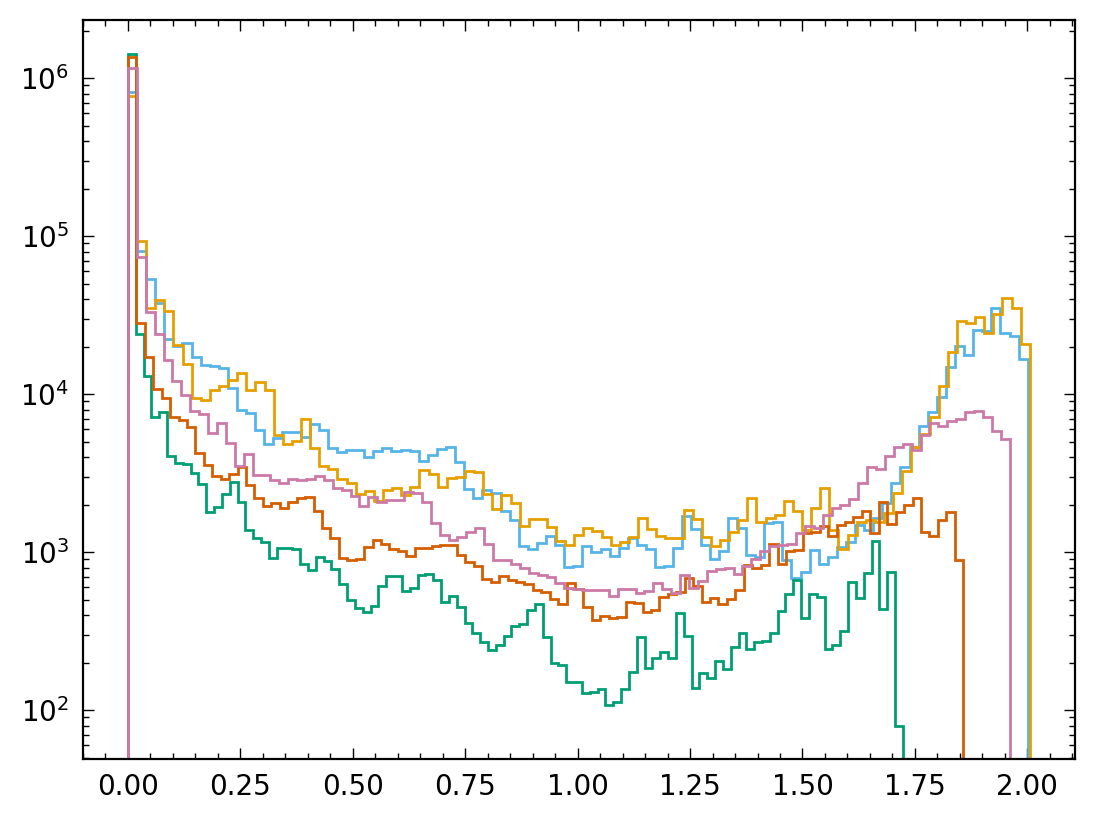

In [4]:
# Inspect distribution of observables
sel = 'peff_clearance'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pHI,stim_pHE
0,-26.795884,0.658795,0.411705,0.118960
1,-6.698971,1.257199,0.393135,0.135512
2,0.700124,0.088091,0.492563,0.027302
3,0.717337,0.117731,0.570777,0.036246
4,0.735609,0.145690,0.623425,0.044320
...,...,...,...,...
100,2.677607,1.994114,0.686488,0.094795
101,2.813581,2.132181,0.691413,0.106020
102,3.349485,0.011641,0.483139,0.032168
103,5.359177,0.060423,0.475352,0.042104


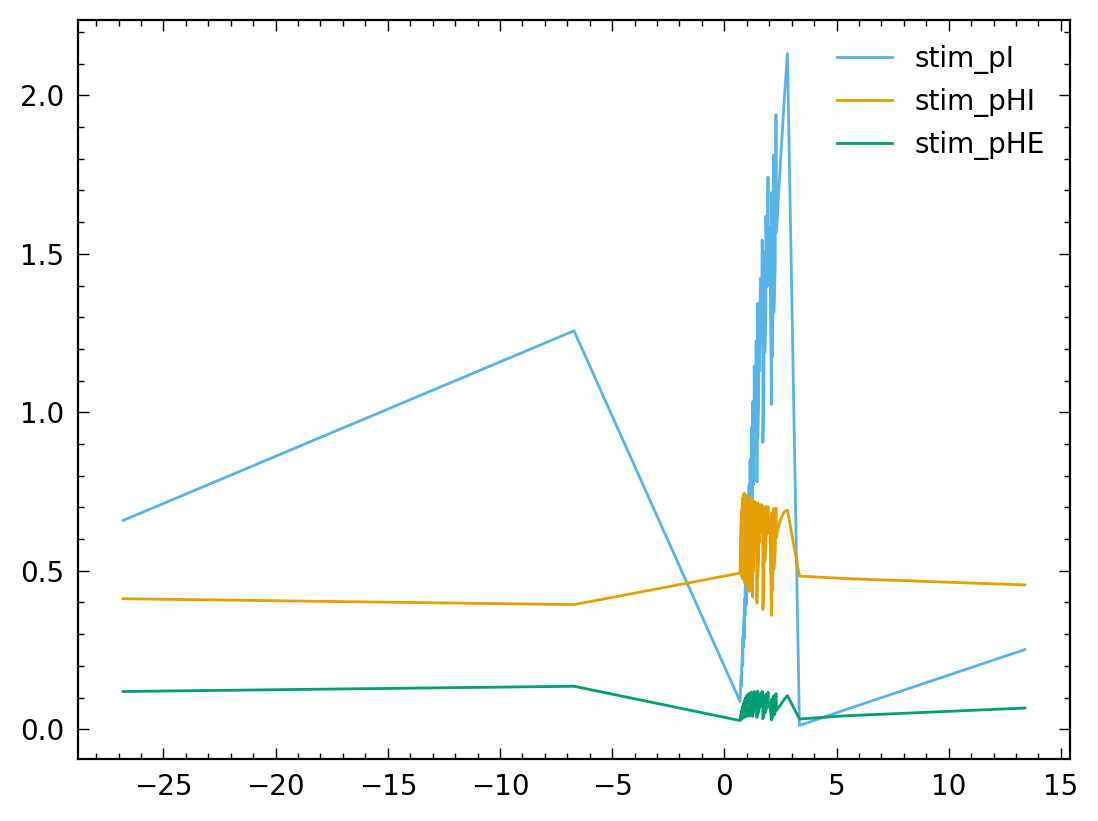

In [5]:
norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pHI', 'stim_pHE']], label = ['stim_pI', 'stim_pHI', 'stim_pHE'])
plt.legend()

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 12
fevals: 12
fevals: 10
fevals: 10


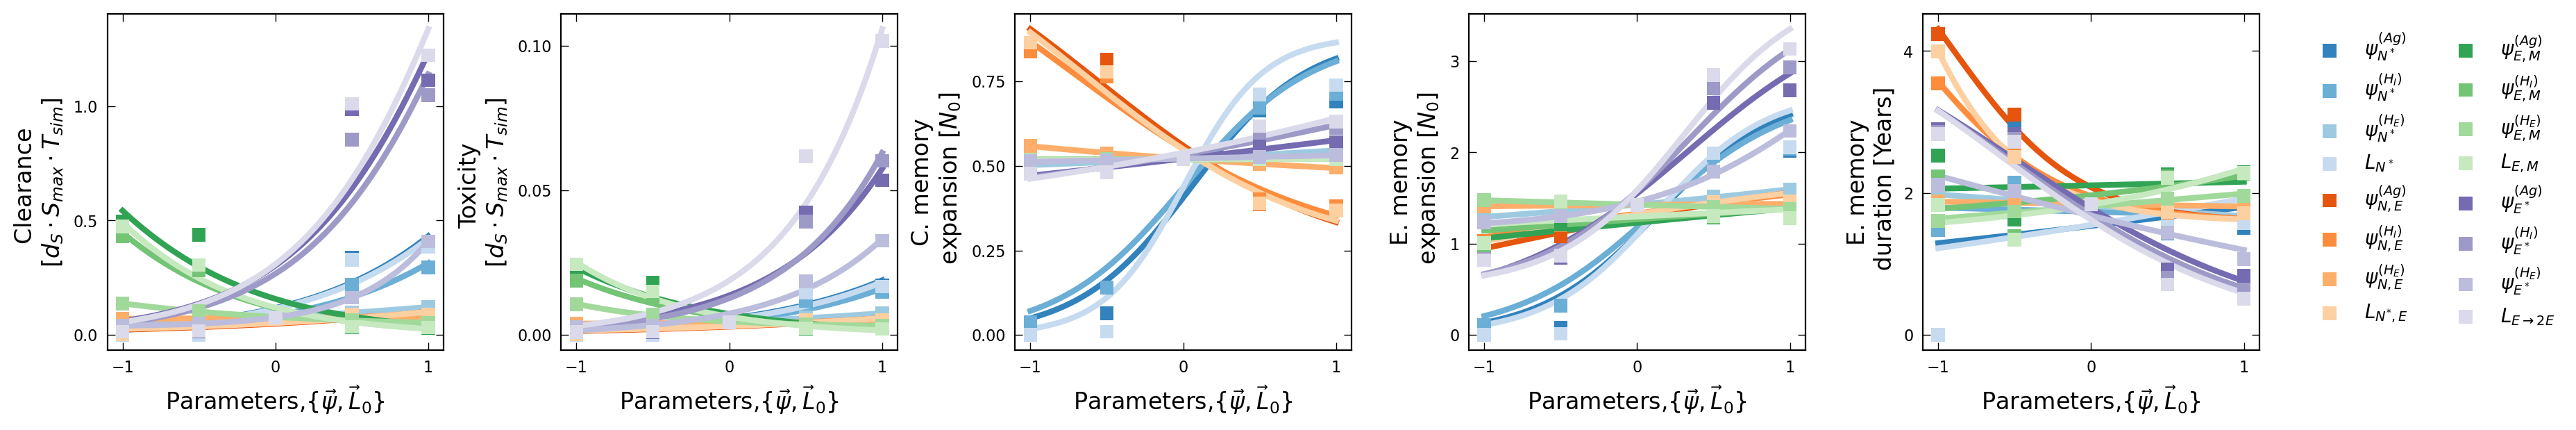

In [6]:
# Fit impact of regulatory parameters on performace: marginalizing over modules

fig, axs = plt.subplots(1, len(perf_vars), 
                              figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    zero_regs = np.concatenate([(module_reg[modules[u]] if u != module_index else []) for u in np.arange(0, len(modules))]).tolist()
    
    x_varname= key_var

    data = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[zero_regs]), axis = 1) == 0.0)]
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = data.loc[(np.sum(np.abs(data[reg_choice]), axis = 1) == np.abs(data[reg_choice[j]]))].groupby(reg_choice[j], as_index = False).mean()
            im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), data_mean[var], 
                              marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
                                edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

            y_max = np.max(data[var].values)
            y_min = np.min(data[var].values)
            y_std = np.std(data[var].values)

            #if var != 'T_max_pI':
            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*L0_max, -2*L0_max], 
                                             [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*L0_max, 2*L0_max]),
                                   maxfev=5000,
                                   full_output = True)

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i].plot(x/np.amax(x), sigmoid_1d(x, *popt), 
                        linestyle='-',
                        linewidth = 3.0,
                        color = cmap_colors[module_index*len(reg_choice) + j], 
                        zorder = 0)

            if module_index + j == 0: 
                axs[i].minorticks_off()
                axs[i].yaxis.set_tick_params(labelbottom=True)
                axs[i].xaxis.set_tick_params(labelbottom=True)
                axs[i].tick_params(axis='both', which='major', labelsize=8)
                axs[i].set_box_aspect(1)
                axs[i].locator_params(axis='y', nbins=4)
                axs[i].locator_params(axis='x', nbins=4)
                axs[i].set_ylabel(perf_labels[i], fontsize = 12)
                axs[i].set_xlabel(r'Parameters,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

        if i == 0:
            print("fevals:", infodict['nfev'])

axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.35, hspace=.35)
plt.savefig('_figs/'+comment+'-'+'regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
# del data

fevals: 10
fevals: 10
fevals: 9
fevals: 8


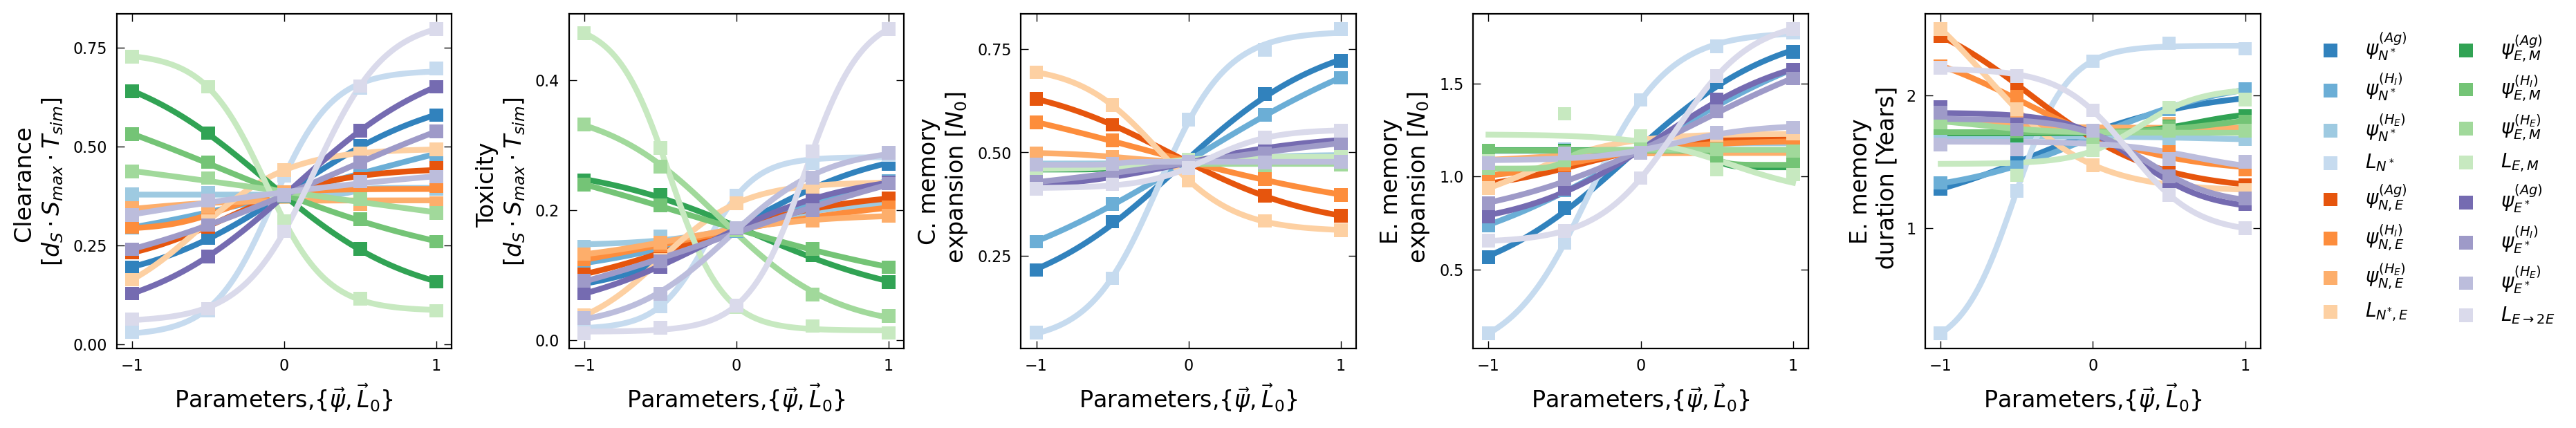

In [7]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
fig, axs = plt.subplots(1, len(perf_vars), 
                              figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    zero_regs = np.concatenate([(module_reg[modules[u]] if u != module_index else []) for u in np.arange(0, len(modules))]).tolist()
    
    x_varname= key_var
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = clustered_mean_df.groupby(reg_choice[j], as_index = False).mean()
            im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), data_mean[var], 
                              marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
                                edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

            y_max = np.max(data_mean[var].values)
            y_min = np.min(data_mean[var].values)
            y_std = np.std(data_mean[var].values)

            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*L0_max, -2*L0_max], 
                                             [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*L0_max, 2*L0_max]),
                                   maxfev=5000,
                                   full_output = True)

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i].plot(x/np.amax(x), sigmoid_1d(x, *popt), 
                        linestyle='-',
                        linewidth = 3.0,
                        color = cmap_colors[module_index*len(reg_choice) + j], 
                        zorder = 0)

            if module_index + j == 0: 
                axs[i].minorticks_off()
                axs[i].yaxis.set_tick_params(labelbottom=True)
                axs[i].xaxis.set_tick_params(labelbottom=True)
                axs[i].tick_params(axis='both', which='major', labelsize=8)
                axs[i].set_box_aspect(1)
                axs[i].locator_params(axis='y', nbins=4)
                axs[i].locator_params(axis='x', nbins=4)
                axs[i].set_ylabel(perf_labels[i], fontsize = 12)
                axs[i].set_xlabel(r'Parameters,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

        if i == 0:
            print("fevals:", infodict['nfev'])

axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.35, hspace=.35)
plt.savefig('_figs/'+comment+'-'+'mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")

fevals: 9
fevals: 13
fevals: 10
fevals: 17


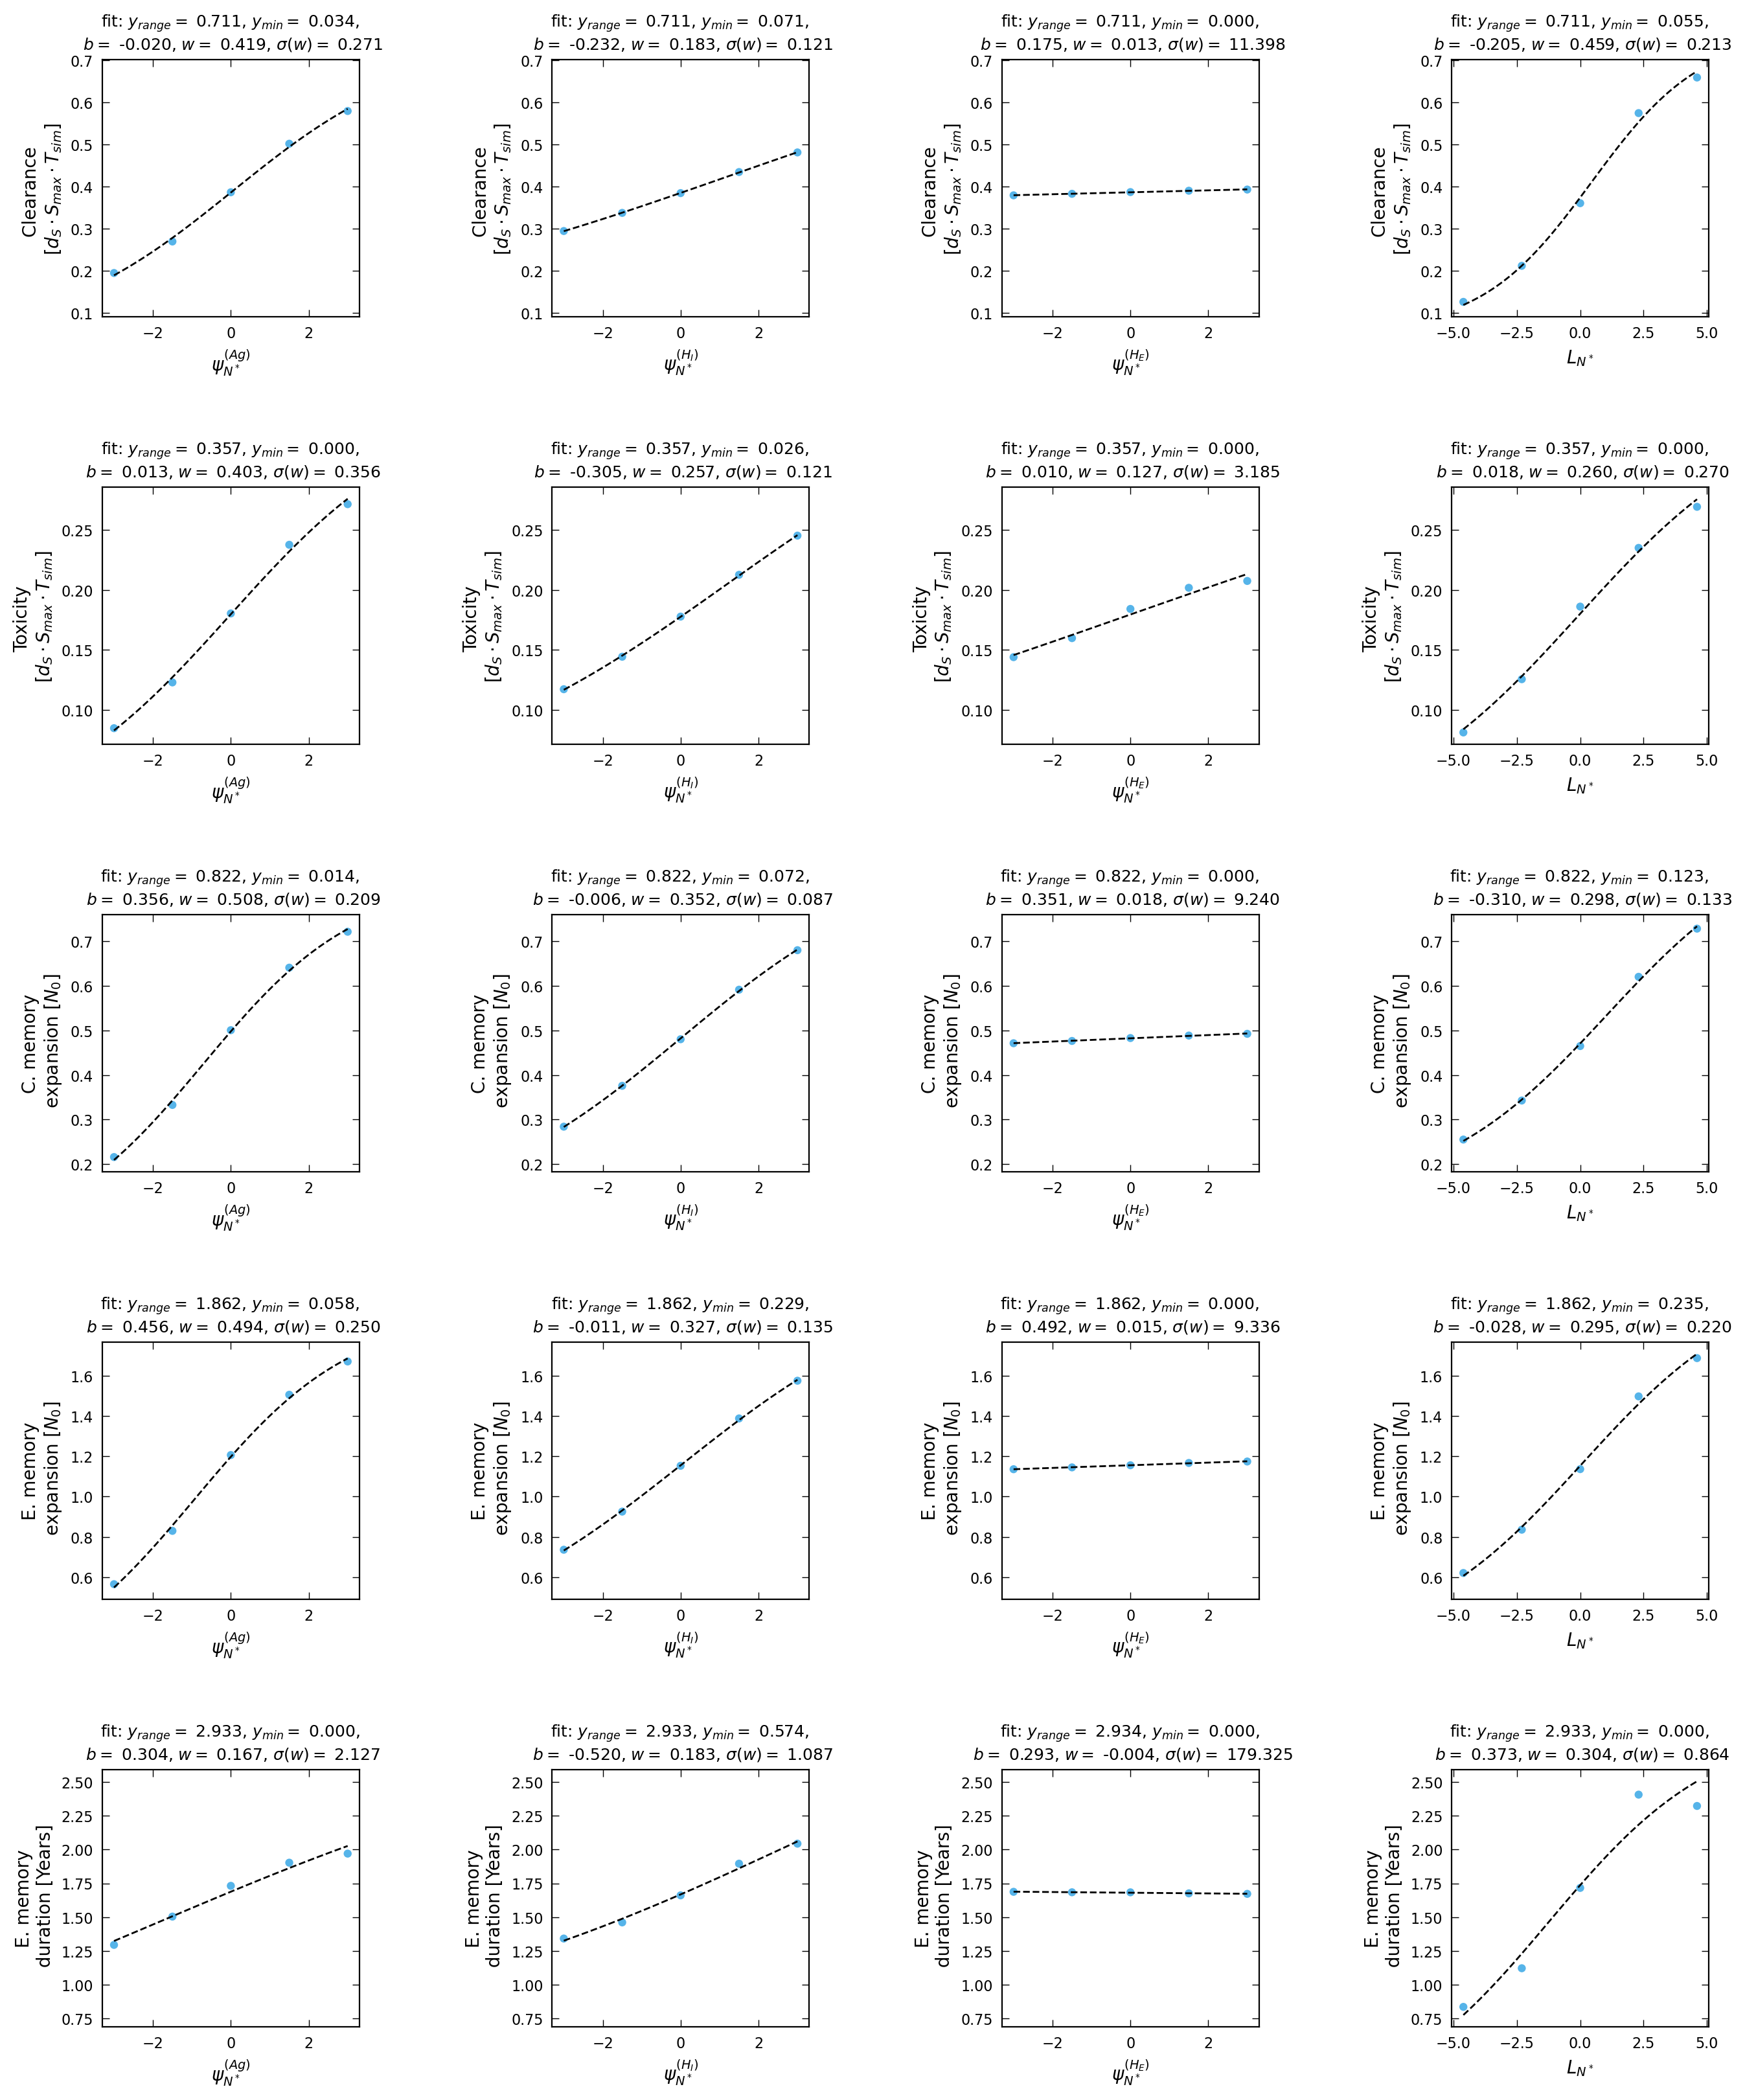

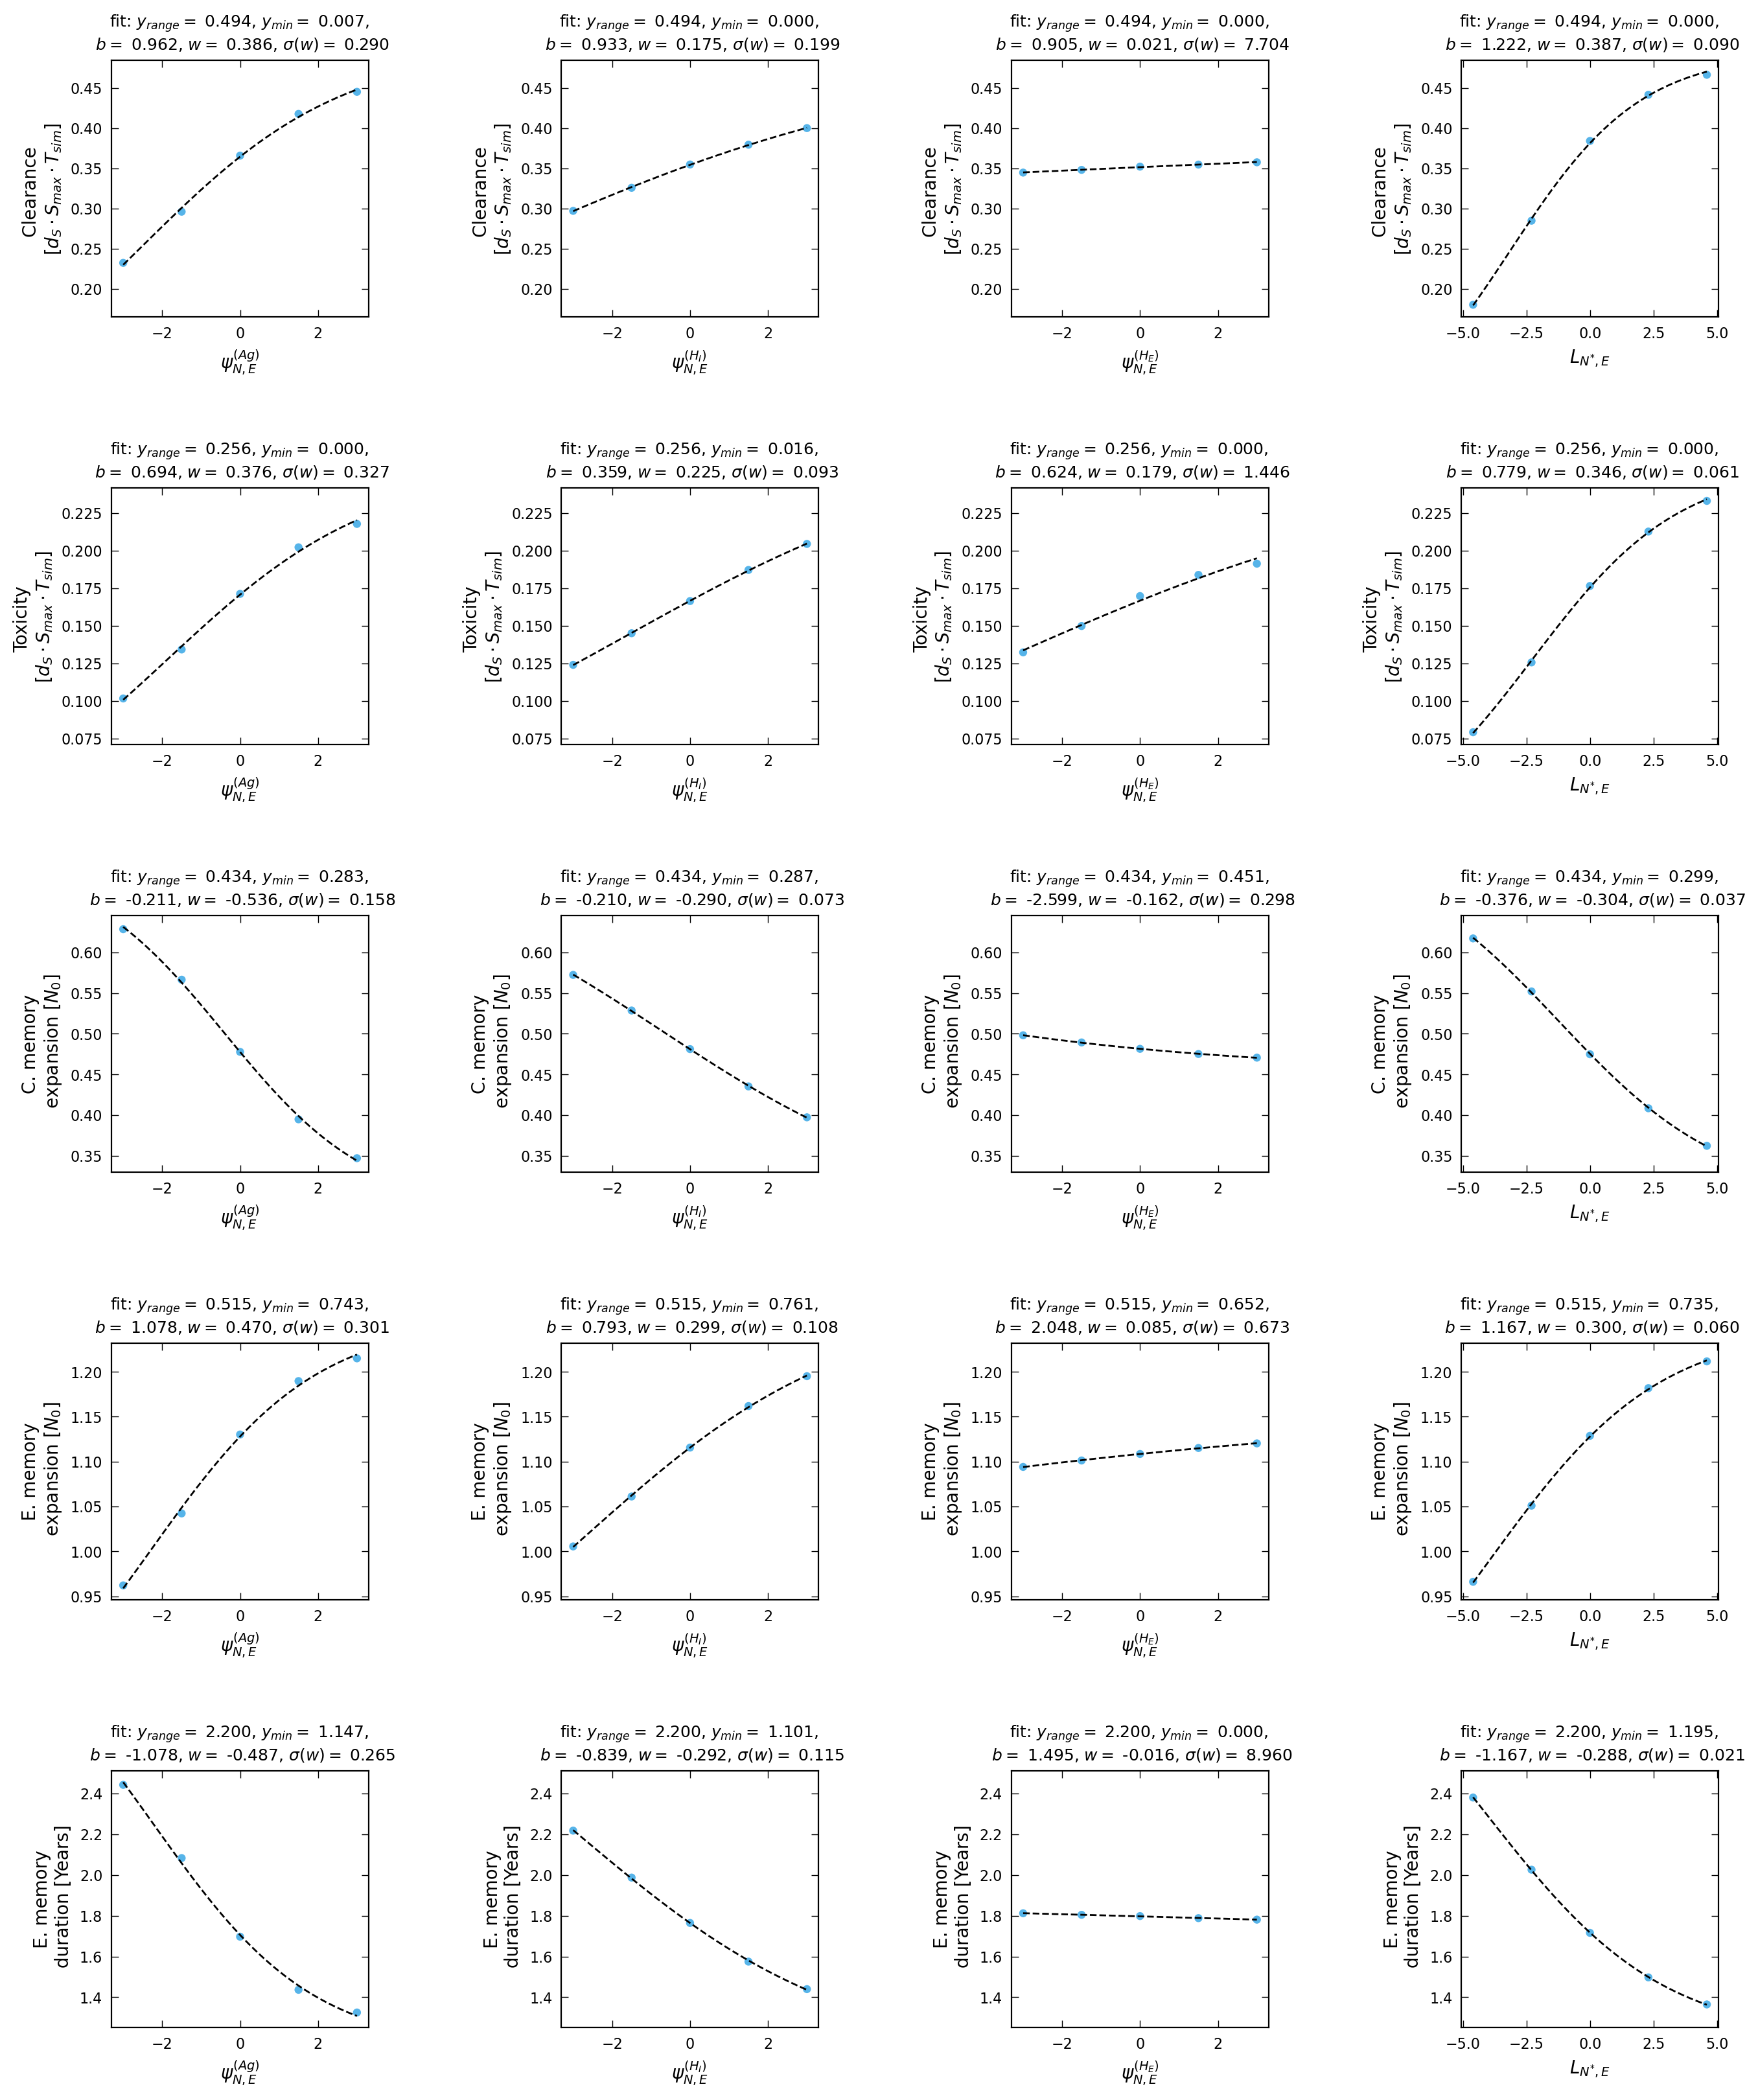

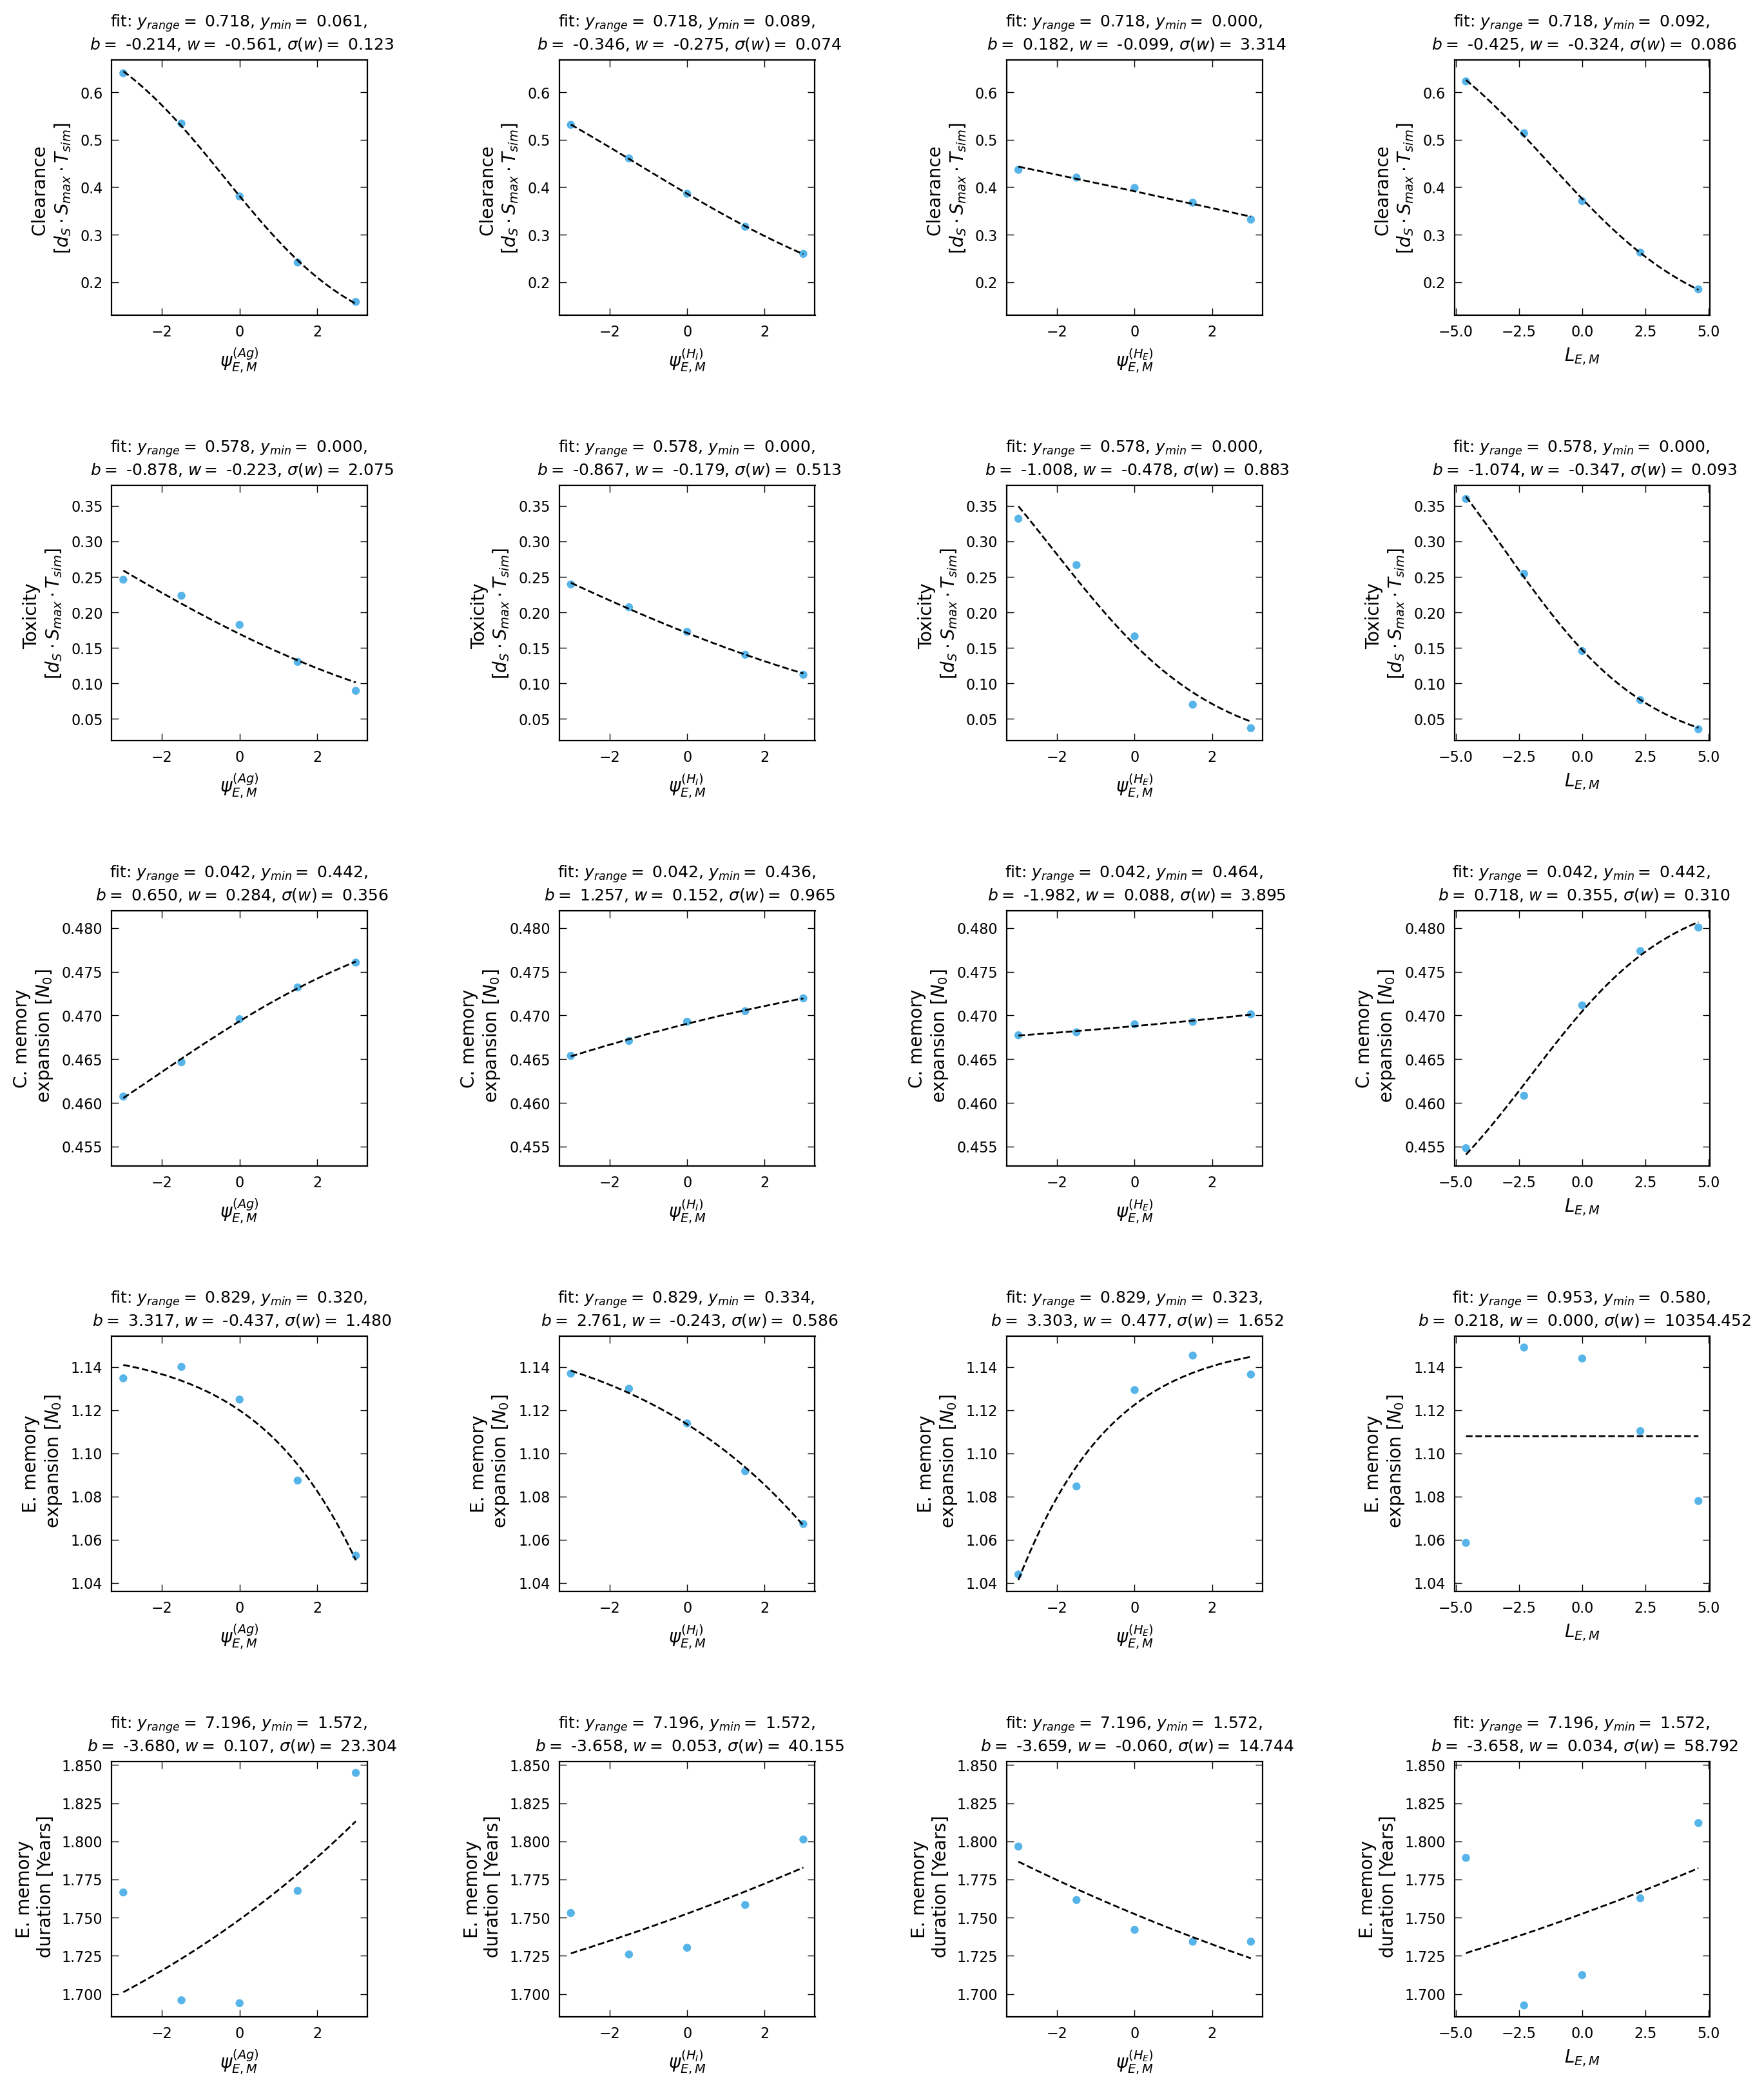

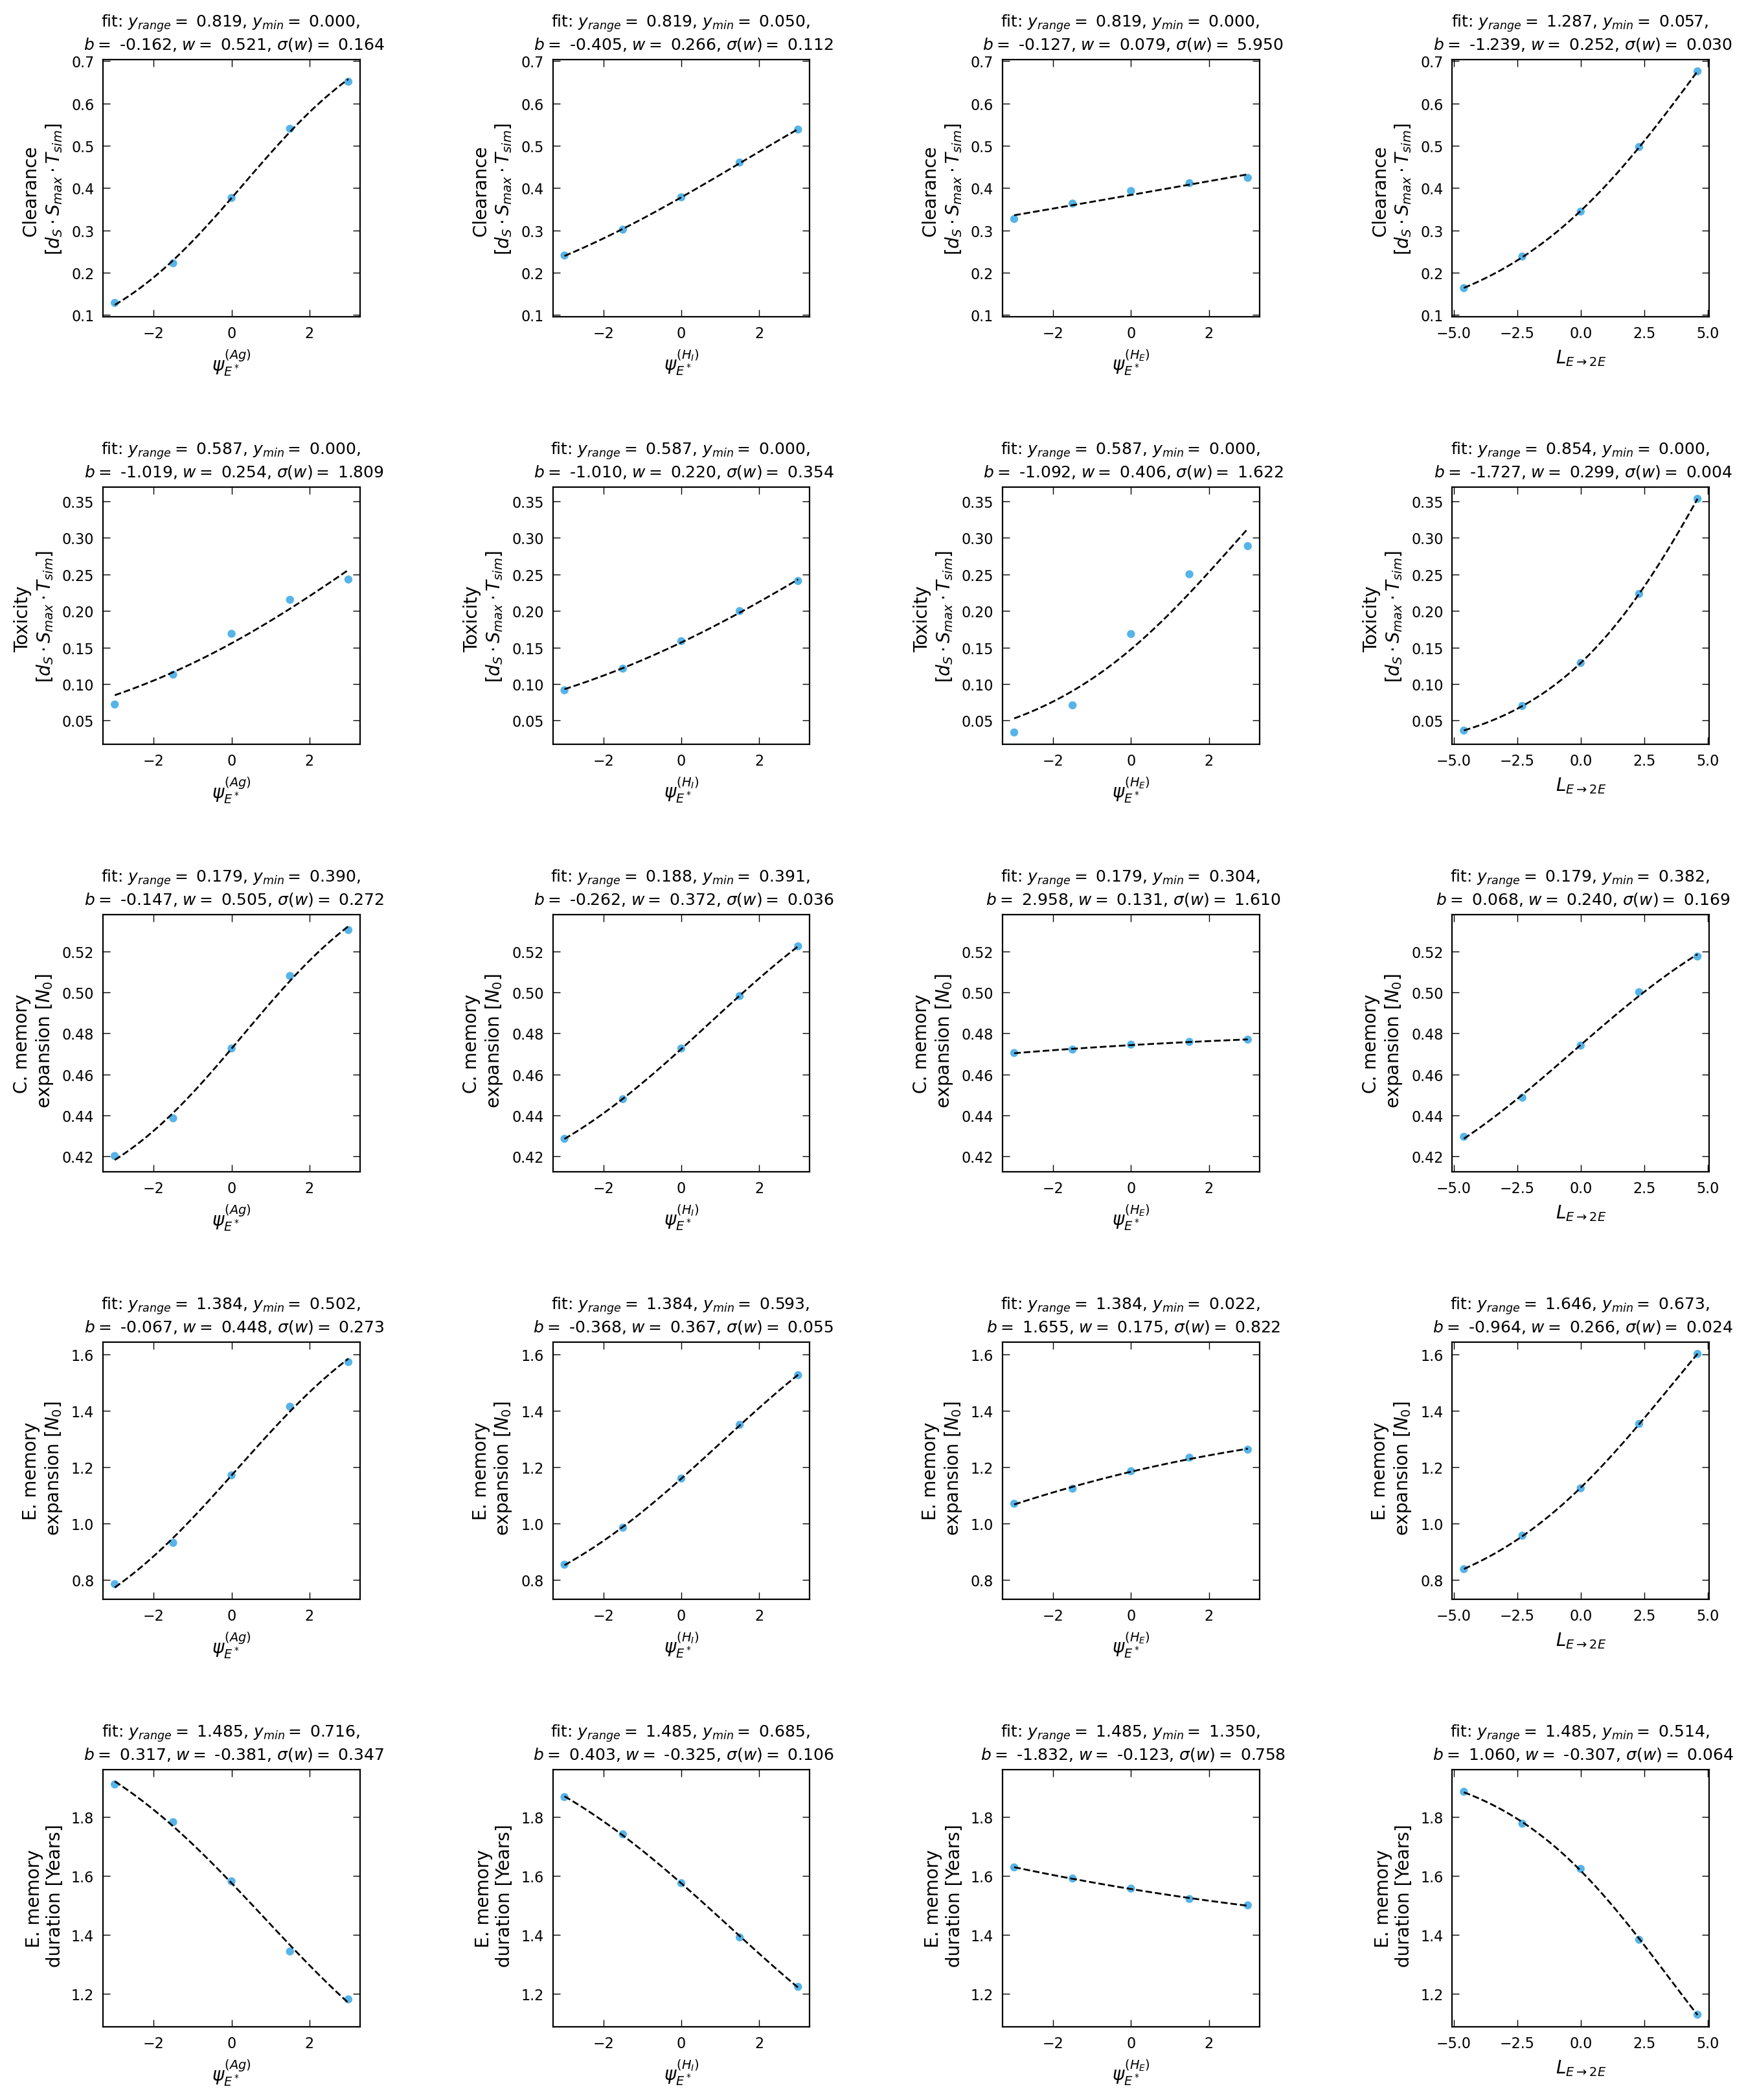

In [7]:
# # Fit impact of regulatory parameters on performace: marginalizing over modules
# for module_index in np.arange(0, len(modules)):
#     reg_choice_label = modules[module_index]
#     reg_choice = module_reg[reg_choice_label]
    
#     x_varname= key_var
#     fig_c, axs = plt.subplots(num_categories, len(reg_choice), 
#                               figsize=(len(reg_choice)*len(reg_choice), np.maximum(3.5, len(reg_choice))*num_categories), sharex='col', sharey='row')

#     data = clustered_mean_df.loc[(clustered_mean_df.K_EH == K_EH)].groupby(reg_choice, as_index = False).mean()
    
#     for i, var in enumerate(perf_vars):
        
#         for j, p in enumerate(signal_classes):
#             data_mean = data.groupby(reg_choice[j], as_index = False).mean()
#             im = axs[i, j].scatter(data_mean[reg_choice[j]], data_mean[var], 
#                               marker = 'o', s = 20, edgecolors = 'None')

#             y_max = np.max(data[var].values)
#             y_min = np.min(data[var].values)
#             y_std = np.std(data[var].values)

#             #if var != 'T_max_pI':
#             popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
#                                    p0 =(y_max - y_min, y_min, 0.0, 0.0),
#                                    method = 'trf', 
#                                    bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*psi_max, -2*psi_max], 
#                                              [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*psi_max, 2*psi_max]),
#                                    maxfev=5000,
#                                    full_output = True)
  
#             sigma_w = np.sqrt(np.diag(pcov))[-1]

#             x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
#             axs[i, j].plot(x, sigmoid_1d(x, *popt), 'k--')

#             axs[i, j].set_title('fit: $y_{range} =$ %5.3f, $y_{min} =$ %5.3f, \n $b=$ %5.3f, $w=$ %5.3f, $\sigma(w) =$ %5.3f' % tuple(popt.tolist() + [sigma_w]), fontsize = 9.0)
                
#             axs[i, j].minorticks_off()
#             axs[i, j].yaxis.set_tick_params(labelbottom=True)
#             axs[i, j].xaxis.set_tick_params(labelbottom=True)
#             axs[i, j].tick_params(axis='both', which='major', labelsize=8)
#             axs[i, j].set_box_aspect(1)
#             axs[i, j].set_ylabel(perf_labels[i], fontsize = 10)
#             axs[i, j].set_xlabel(reg_label[module_index*len(reg_choice) + j ], fontsize = 10)

#         if i == 0:
#             print("fevals:", infodict['nfev'])
    
#     fig_c.subplots_adjust(wspace=.75, hspace=0.5)
#     plt.savefig('_figs/'+comment+'-'+reg_choice_label+'-mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
#     del data

In [8]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [9]:
# Regress Performance measures on regulation parameters
num_cpu = 133
variables = reg

def model(input, fit = "non-linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max - y_min, y_min] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([(y_max - y_min)/2, 0.0 if y_min >= 0.0 else 2*y_min] + len(variables)*[-3.0*L0_max] + num_modules*[-3.0*L0_max], 
                                     [(1.5 if perf != "T_eM_min" else 1.0)*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.01, y_min if y_min > 0 else + y_std + 0.01] + len(variables)*[3.0*L0_max] + num_modules*[3.0*L0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, input['harm_pI_noprotection'].values[0],
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHI'].values),
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHE'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [10]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [11]:
# View result
perf_choice = 2 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)])

,y_range,y_min,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_HI,sigma_psi_Na_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_HI,sigma_psi_EE_HE,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
2,1.222370,3.591794e-33,0.036005,0.081278,0.001611,1.854769,-0.008711,-0.017148,-0.000588,-0.129455,0.111038,-2.180986,-0.055668,-0.013573,0.015014,0.016214,0.000098,0.277186,0.375444,1.005432,13.815488,0.368958,0.013305,0.000420,0.003275,0.003289,0.003272,0.022549,0.001929,0.001969,0.001915,0.003703,1.663931,62.450419,1.578238,1.011988,0.001510,0.001510,0.001508,0.001553,0.003981,0.041174,187.706411,0.009487,0.01,100000000.0,0.0,50000.0,30.000000,10000000.0,0.0,0.260522,0.814913,0.0,0.000000,2.0,0.113437,0.288068,0.000000,0.040967,0.026400,0.003452,NaN
7,1.217915,1.567532e-33,0.036152,0.081817,0.003494,1.852544,-0.009104,-0.017520,-0.002257,-0.133167,-0.086814,2.193050,-0.030346,0.031698,0.014798,0.016060,0.000116,0.277087,0.372446,1.063817,13.815510,0.378394,0.012423,0.000425,0.003267,0.003281,0.003263,0.022442,0.001999,0.002036,0.001986,0.003751,1.593424,62.651121,1.532928,1.007210,0.001512,0.001513,0.001510,0.001555,0.003971,0.040187,188.292048,0.009496,0.01,100000000.0,0.0,50000.0,94.868330,10000000.0,0.0,0.264218,0.811943,0.0,0.001827,2.0,0.114754,0.291786,0.000000,0.040967,0.026400,0.009434,NaN
12,1.213565,3.712473e-35,0.036250,0.082190,0.006786,1.852673,-0.008985,-0.017807,-0.005366,-0.135260,-0.022420,2.115720,0.018837,0.031341,0.014884,0.016103,0.000325,0.277218,0.371923,1.093885,13.815510,0.382923,0.011962,0.000427,0.003265,0.003280,0.003262,0.022446,0.002036,0.002074,0.002028,0.003775,1.992890,73.506037,1.991122,1.312330,0.001514,0.001515,0.001512,0.001557,0.003969,0.039653,220.969015,0.009496,0.01,100000000.0,0.0,50000.0,300.000000,10000000.0,0.0,0.265611,0.809043,0.0,0.001734,2.0,0.115277,0.293190,0.000000,0.040964,0.026400,0.021573,NaN
17,1.210739,3.222875e-37,0.036800,0.082942,0.012218,1.850164,-0.008965,-0.017769,-0.009415,-0.135642,-0.037733,-0.008748,2.118062,-0.015243,0.014787,0.016118,0.000761,0.277463,0.372076,1.100483,13.815511,0.384276,0.011852,0.000427,0.003267,0.003282,0.003263,0.022316,0.002045,0.002082,0.002046,0.003780,2.000328,1.984234,73.684239,1.296245,0.001516,0.001516,0.001514,0.001557,0.003970,0.039566,221.497948,0.009490,0.01,100000000.0,0.0,50000.0,948.683298,10000000.0,0.0,0.265537,0.807160,0.0,0.001736,2.0,0.115262,0.293096,0.000000,0.040957,0.026400,0.041724,NaN
22,1.211093,4.825622e-36,0.037562,0.084487,0.021539,1.845090,-0.008908,-0.017889,-0.015947,-0.135294,2.129806,-0.003513,-0.023113,0.006255,0.014744,0.016151,0.001405,0.277453,0.371174,1.101015,13.815510,0.384622,0.011886,0.000427,0.003269,0.003284,0.003266,0.022070,0.002047,0.002085,0.002074,0.003783,72.879059,1.927855,1.933912,1.256462,0.001517,0.001517,0.001515,0.001558,0.003973,0.039685,219.062300,0.009496,0.01,100000000.0,0.0,50000.0,3000.000000,10000000.0,0.0,0.265666,0.807395,0.0,0.001748,2.0,0.115361,0.293230,0.000000,0.040937,0.026400,0.071379,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,1.291704,1.141919e-30,0.209283,2.038216,0.010221,1.696509,-0.008737,-0.091484,-0.003256,-0.114864,0.000758,0.003656,0.004008,-0.001376,0.045825,0.494369,0.000498,0.441517,0.640380,0.654780,11.798638,0.018058,6.628404,0.000299,0.0035

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for clearance, toxicity and memory are above 0.80.

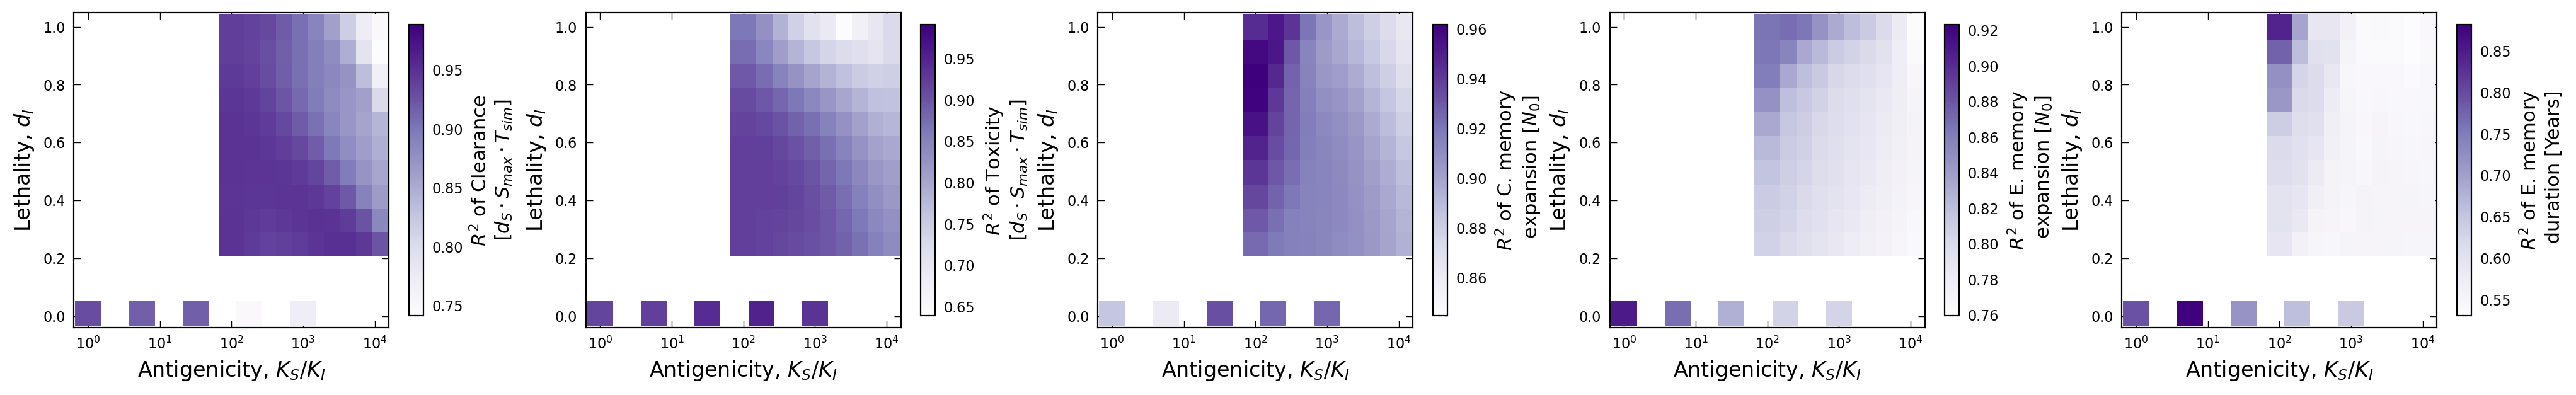

In [12]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$K_{S}/K_{I}$", "Lethality, "+r"$d_{I}$"]
size = 2500/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)]
    model_r_sq = 1 - data.rmse**2/data.y_std**2
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(K_SE/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 K_SE/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.30, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared'+'.png', dpi=150, bbox_inches="tight")

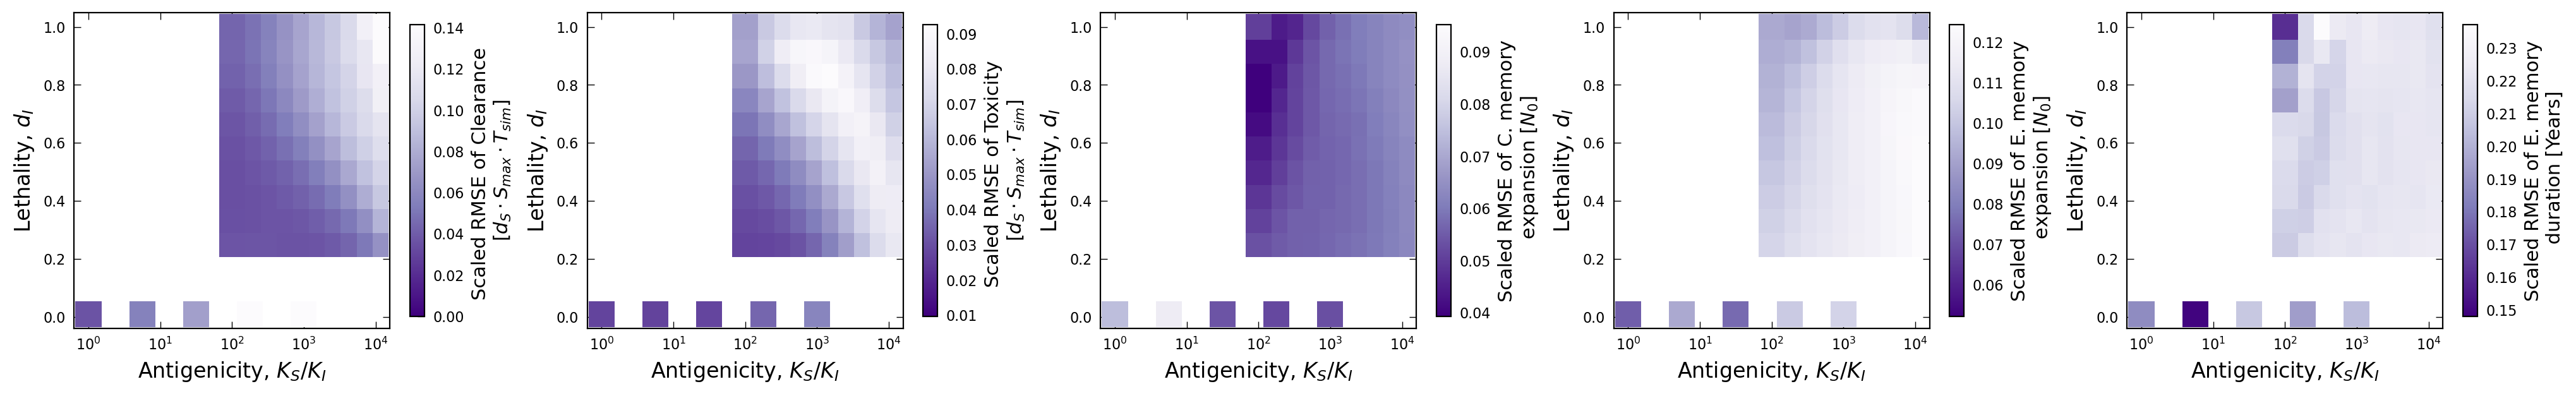

In [25]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$K_{S}/K_{I}$", "Lethality, "+r"$d_{I}$"]
size = 2500/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)]
    model_rmse_over_max = data.rmse/data.y_range
    z_label = "Scaled RMSE of "+perf_labels[i]
    
    im = axs[i].scatter(K_SE/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 K_SE/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, 
                        c = model_rmse_over_max, cmap='Purples_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.30, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-scaled-rmse'+'.png', dpi=150, bbox_inches="tight")

Effector memory expansion appears challenging to fit based on the $R^2$ values. Looks much better when we look at scaled RMSE. Rationalize by observing tha effector memory expansion has non-monotonic dependence on some variables which can lead to a low variance estimate, and make the $R^2$ values look bad.

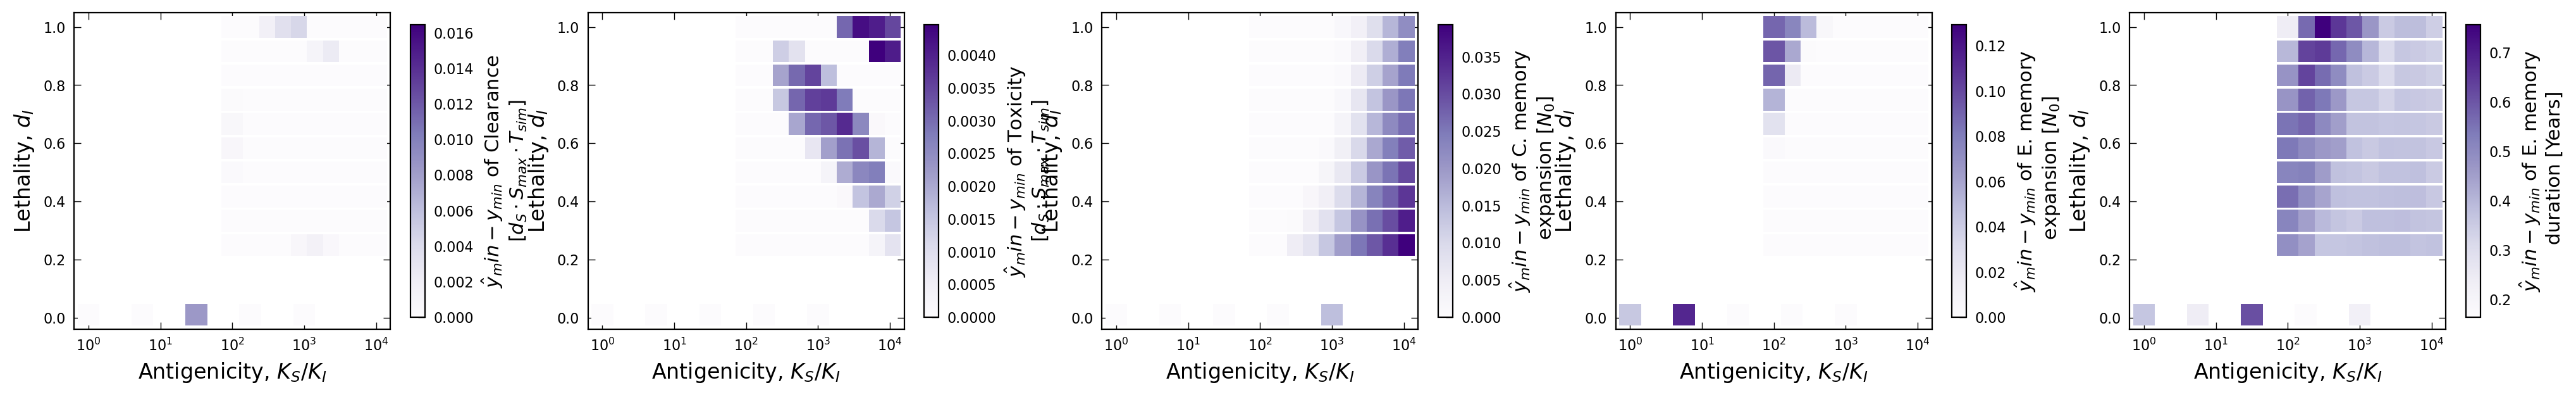

In [21]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)]
    z_label = r"$\hat{y}_min - y_{min}$ of "+perf_labels[i]
    
    im = axs[i].scatter(K_SE/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 K_SE/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, c = data.y_min - data.min_perf, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.30, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_min'+'.png', dpi=150, bbox_inches="tight")

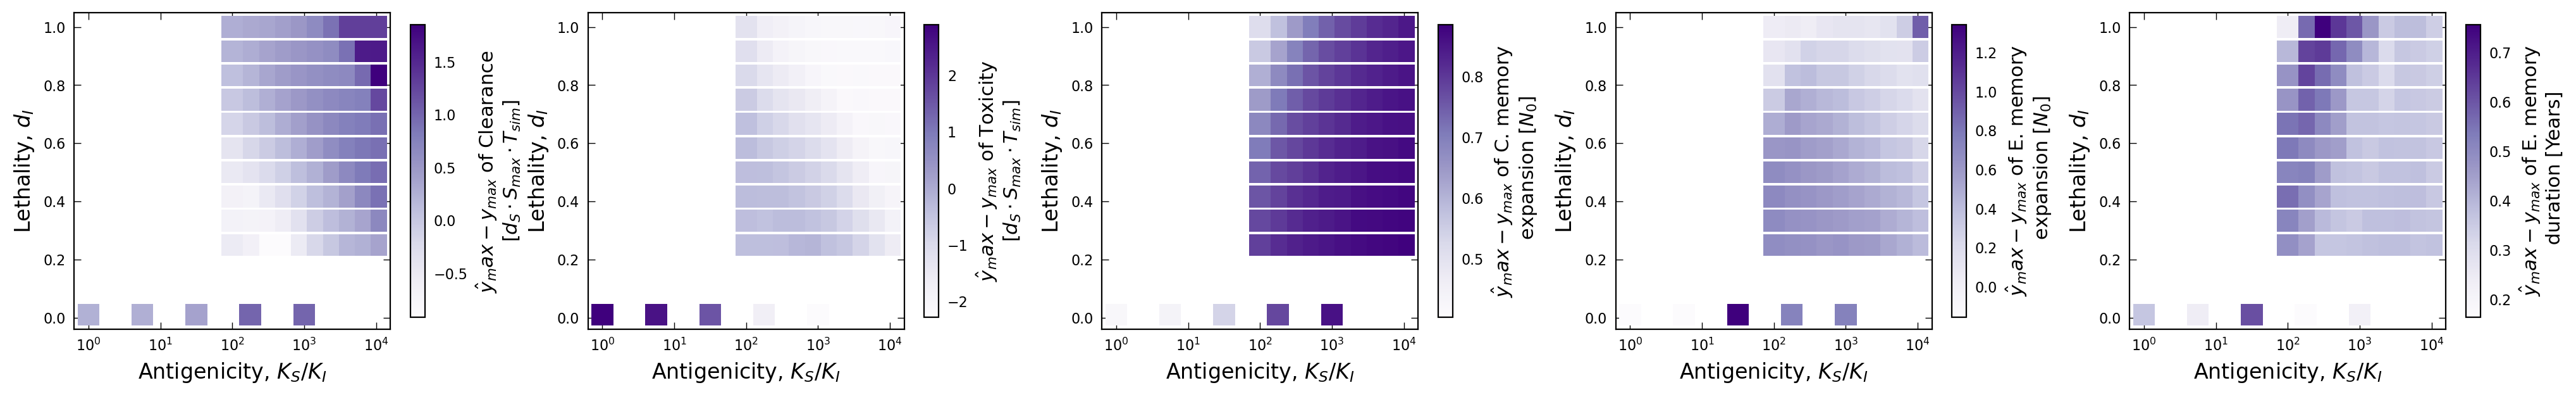

In [22]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)]
    z_label = r"$\hat{y}_max - y_{max}$ of "+perf_labels[i]
    
    im = axs[i].scatter(K_SE/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 K_SE/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, c = data.y_range + data.y_min - data.max_perf, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.30, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_max'+'.png', dpi=150, bbox_inches="tight")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for clearance/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high clearance/toxicity in this module.

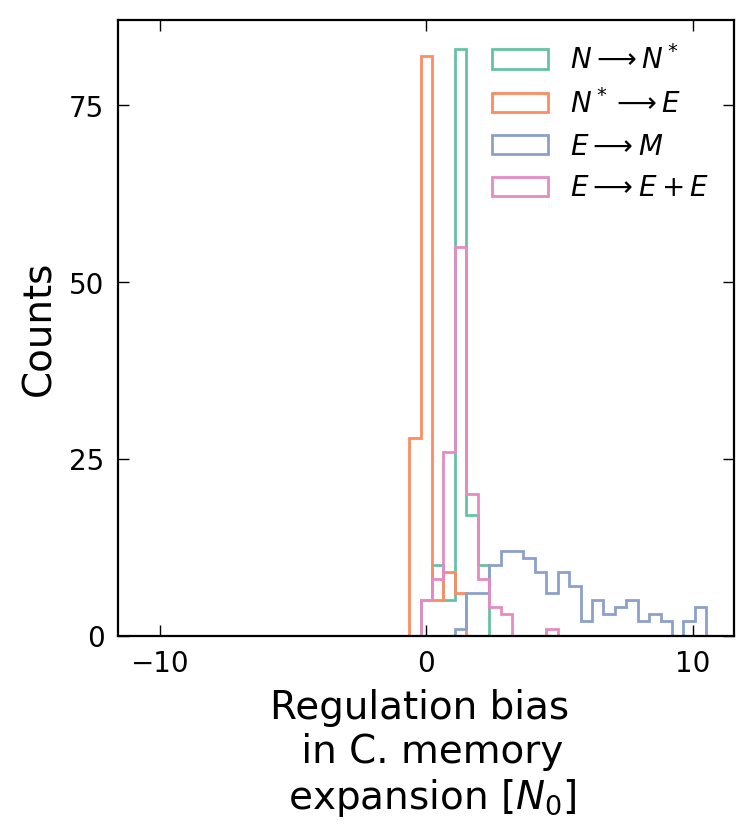

In [15]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data['K_EH'] == K_EH)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-3.5*psi_max, 3.5*psi_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf_choice], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

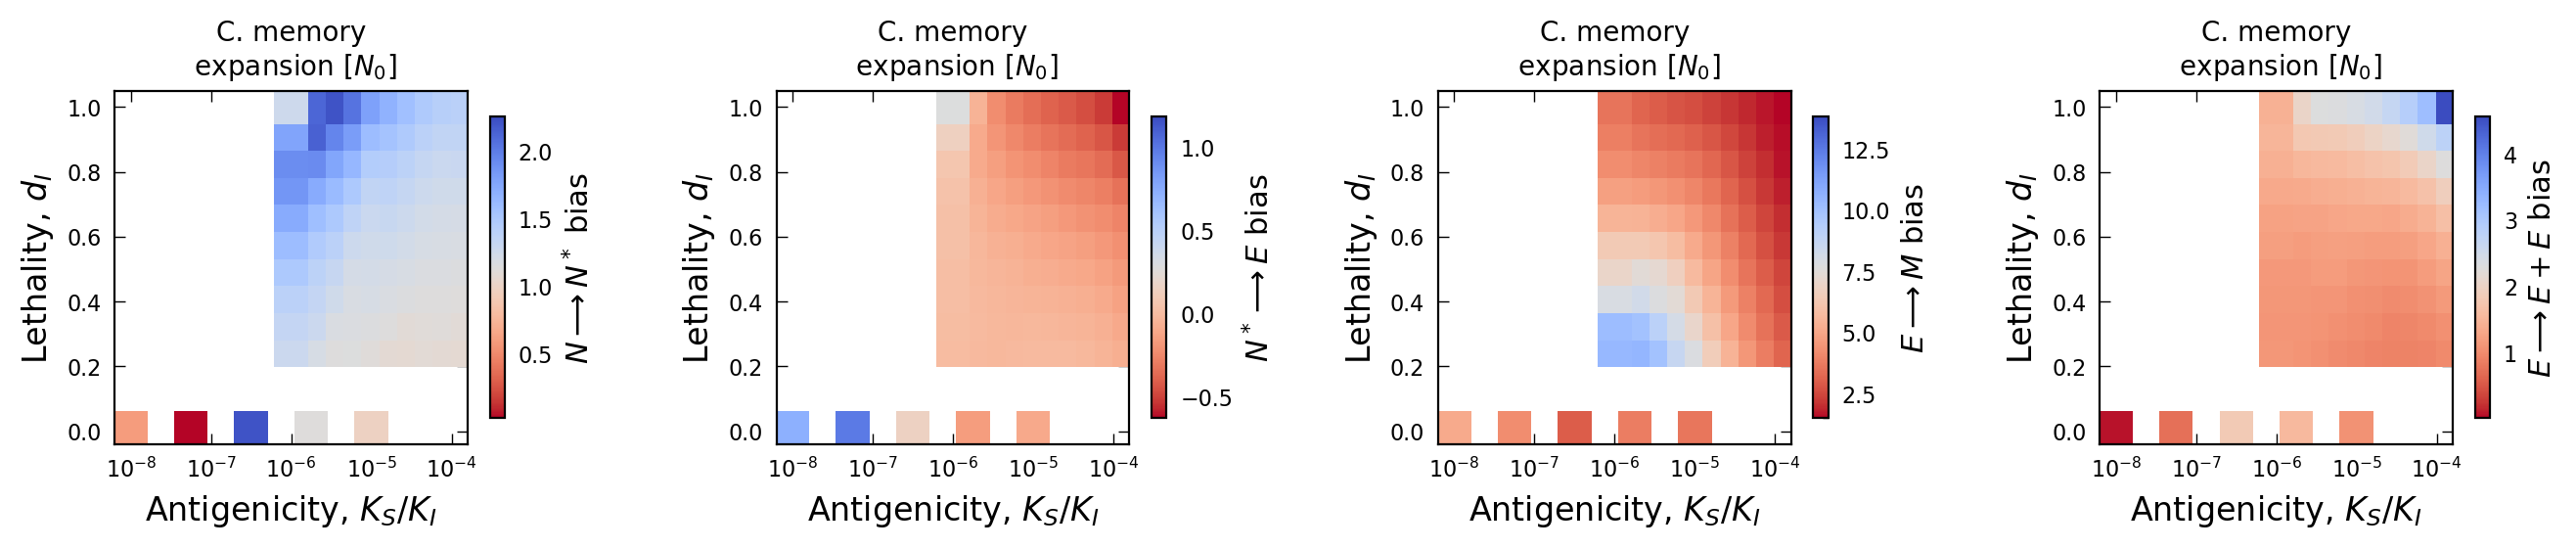

In [16]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
size = 1750/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data['K_EH'] == K_EH)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    
    im = axs[i].scatter(1/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, c = data[z_varname], cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)
    axs[i].set_title(perf_labels[perf_choice], fontsize = 10.0)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate leads to above-median performance/cost. It would be useful to convert these to rates.

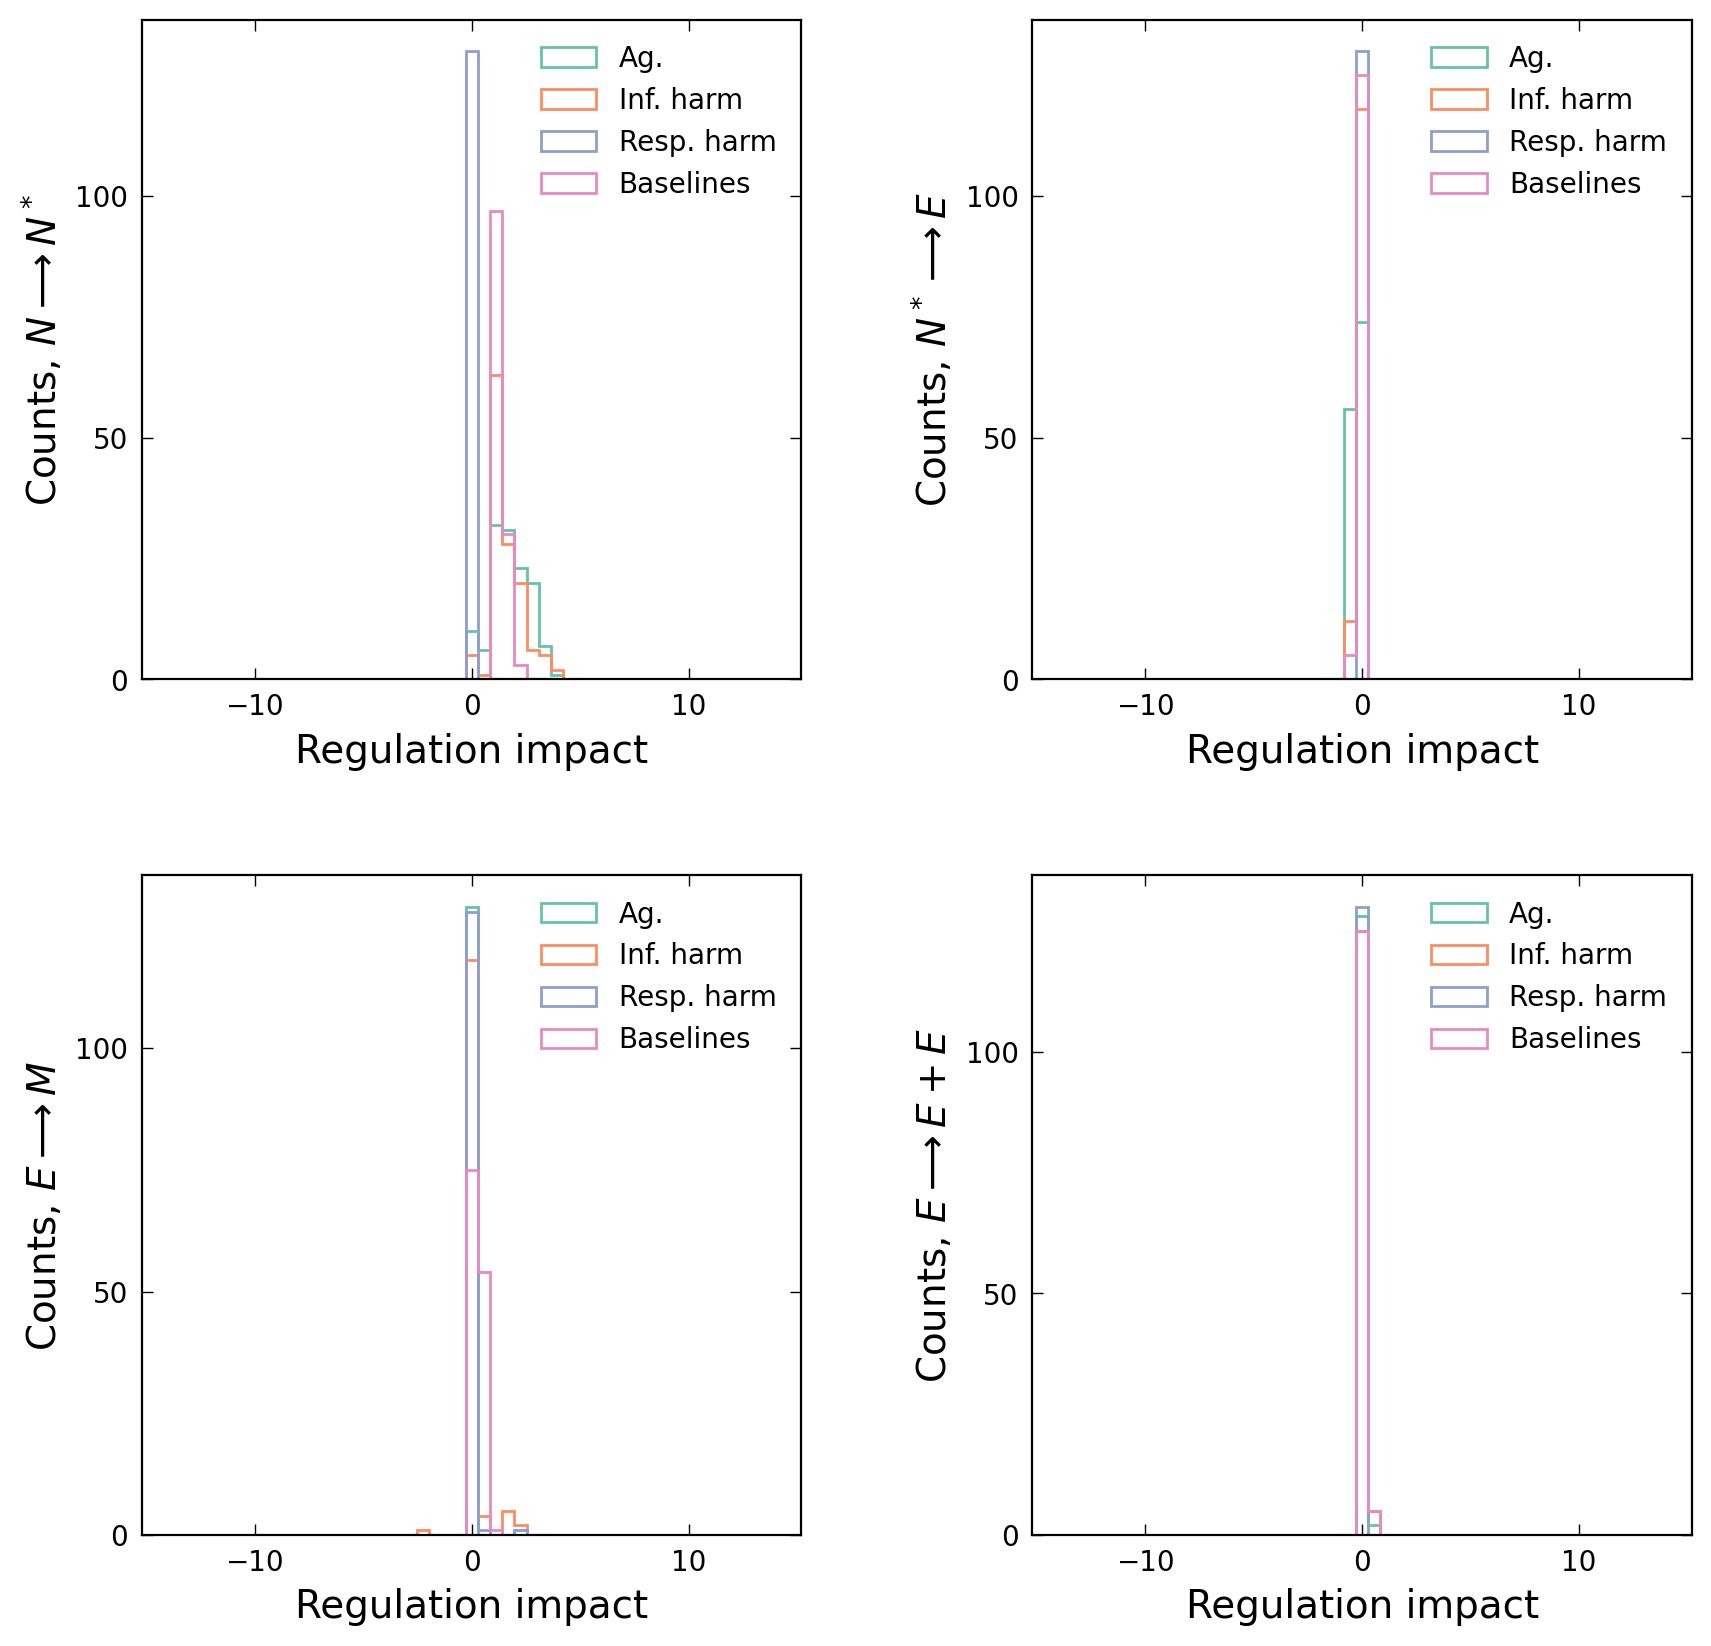

In [17]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data['K_EH'] == K_EH)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-3.0*L0_max, 3.0*L0_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [18]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == 0.0)])

,y_range,y_min,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_HI,sigma_psi_Na_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_HI,sigma_psi_EE_HE,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
2,1.222370,3.591794e-33,0.036005,0.081278,0.001611,1.854769,-0.008711,-0.017148,-0.000588,-0.129455,0.111038,-2.180986,-0.055668,-0.013573,0.015014,0.016214,0.000098,0.277186,0.375444,1.005432,13.815488,0.368958,0.013305,0.000420,0.003275,0.003289,0.003272,0.022549,0.001929,0.001969,0.001915,0.003703,1.663931,62.450419,1.578238,1.011988,0.001510,0.001510,0.001508,0.001553,0.003981,0.041174,187.706411,0.009487,0.01,100000000.0,0.0,50000.0,30.000000,10000000.0,0.0,0.260522,0.814913,0.0,0.000000,2.0,0.113437,0.288068,0.0,0.040967,0.0264,0.003452,NaN
7,1.217915,1.567532e-33,0.036152,0.081817,0.003494,1.852544,-0.009104,-0.017520,-0.002257,-0.133167,-0.086814,2.193050,-0.030346,0.031698,0.014798,0.016060,0.000116,0.277087,0.372446,1.063817,13.815510,0.378394,0.012423,0.000425,0.003267,0.003281,0.003263,0.022442,0.001999,0.002036,0.001986,0.003751,1.593424,62.651121,1.532928,1.007210,0.001512,0.001513,0.001510,0.001555,0.003971,0.040187,188.292048,0.009496,0.01,100000000.0,0.0,50000.0,94.868330,10000000.0,0.0,0.264218,0.811943,0.0,0.001827,2.0,0.114754,0.291786,0.0,0.040967,0.0264,0.009434,NaN
12,1.213565,3.712473e-35,0.036250,0.082190,0.006786,1.852673,-0.008985,-0.017807,-0.005366,-0.135260,-0.022420,2.115720,0.018837,0.031341,0.014884,0.016103,0.000325,0.277218,0.371923,1.093885,13.815510,0.382923,0.011962,0.000427,0.003265,0.003280,0.003262,0.022446,0.002036,0.002074,0.002028,0.003775,1.992890,73.506037,1.991122,1.312330,0.001514,0.001515,0.001512,0.001557,0.003969,0.039653,220.969015,0.009496,0.01,100000000.0,0.0,50000.0,300.000000,10000000.0,0.0,0.265611,0.809043,0.0,0.001734,2.0,0.115277,0.293190,0.0,0.040964,0.0264,0.021573,NaN
17,1.210739,3.222875e-37,0.036800,0.082942,0.012218,1.850164,-0.008965,-0.017769,-0.009415,-0.135642,-0.037733,-0.008748,2.118062,-0.015243,0.014787,0.016118,0.000761,0.277463,0.372076,1.100483,13.815511,0.384276,0.011852,0.000427,0.003267,0.003282,0.003263,0.022316,0.002045,0.002082,0.002046,0.003780,2.000328,1.984234,73.684239,1.296245,0.001516,0.001516,0.001514,0.001557,0.003970,0.039566,221.497948,0.009490,0.01,100000000.0,0.0,50000.0,948.683298,10000000.0,0.0,0.265537,0.807160,0.0,0.001736,2.0,0.115262,0.293096,0.0,0.040957,0.0264,0.041724,NaN
22,1.211093,4.825622e-36,0.037562,0.084487,0.021539,1.845090,-0.008908,-0.017889,-0.015947,-0.135294,2.129806,-0.003513,-0.023113,0.006255,0.014744,0.016151,0.001405,0.277453,0.371174,1.101015,13.815510,0.384622,0.011886,0.000427,0.003269,0.003284,0.003266,0.022070,0.002047,0.002085,0.002074,0.003783,72.879059,1.927855,1.933912,1.256462,0.001517,0.001517,0.001515,0.001558,0.003973,0.039685,219.062300,0.009496,0.01,100000000.0,0.0,50000.0,3000.000000,10000000.0,0.0,0.265666,0.807395,0.0,0.001748,2.0,0.115361,0.293230,0.0,0.040937,0.0264,0.071379,NaN


In [19]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == b_C)])

,y_range,y_min,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_HI,sigma_psi_Na_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_HI,sigma_psi_EE_HE,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
527,2.624295,1.087551e-02,2.803333,0.917264,0.029282,0.967240,-0.622062,-0.169167,-0.019054,-0.278119,0.127749,0.019865,0.035070,0.638229,0.162329,0.039359,0.002500,0.092900,0.987679,-0.030187,8.511115,0.823278,0.020336,0.000569,0.007773,0.003732,0.002698,0.002288,0.001857,0.001116,0.001020,0.000656,0.180978,0.181348,0.181481,0.478739,0.002882,0.001295,0.001132,0.001621,0.003681,0.003568,2.282598,0.025553,0.01,1.000000e+05,0.1,50000.0,30.000000,10000000.0,1000000.0,0.527170,1.749530,0.0,0.450249,2.0,0.138511,0.494035,2.651569,1.377960,0.449834,0.045767,-6.698971
532,2.582795,1.033452e-02,2.799320,0.914411,0.048484,0.971898,-0.610511,-0.165529,-0.029131,-0.275469,0.164539,0.031251,0.022058,0.399689,0.165746,0.039679,0.004303,0.096337,0.993576,-0.031111,6.330951,0.919393,0.018411,0.000567,0.007661,0.003678,0.002666,0.002274,0.001815,0.001092,0.001001,0.000647,0.056826,0.055685,0.055627,0.097709,0.002928,0.001341,0.001188,0.001681,0.003648,0.003570,0.497358,0.025029,0.01,1.000000e+05,0.1,50000.0,94.868330,10000000.0,1000000.0,0.531223,1.721863,0.0,0.454835,2.0,0.137886,0.496504,2.651569,1.339491,0.431557,0.070881,-6.698971
537,2.557790,1.055821e-02,2.797569,0.911032,0.076007,0.978619,-0.604777,-0.163388,-0.046967,-0.275491,0.188841,0.038342,0.022016,0.266486,0.163930,0.039331,0.007478,0.097521,0.990501,-0.039338,5.058561,0.983693,0.017963,0.000562,0.007598,0.003647,0.002656,0.002277,0.001791,0.001079,0.000996,0.000644,0.029163,0.025964,0.025846,0.039468,0.002989,0.001384,0.001234,0.001761,0.003622,0.003555,0.229833,0.025557,0.01,1.000000e+05,0.1,50000.0,300.000000,10000000.0,1000000.0,0.530474,1.705194,0.0,0.454845,2.0,0.137071,0.496365,2.651569,1.292736,0.411137,0.113456,-6.698971
542,2.543229,1.106428e-02,2.802610,0.908815,0.116634,0.989942,-0.599935,-0.159277,-0.076629,-0.278001,0.190699,0.038867,0.027568,0.189132,0.158704,0.037942,0.012606,0.097566,0.982118,-0.055889,4.112353,1.038961,0.018344,0.000551,0.007537,0.003616,0.002654,0.002288,0.001759,0.001062,0.000997,0.000641,0.018118,0.013461,0.013354,0.019481,0.003055,0.001421,0.001284,0.001861,0.003582,0.003509,0.136875,0.026695,0.01,1.000000e+05,0.1,50000.0,948.683298,10000000.0,1000000.0,0.525521,1.695486,0.0,0.448866,2.0,0.135330,0.494285,2.651569,1.202355,0.364368,0.181440,-6.698971
547,2.531287,1.433186e-02,2.823749,0.909819,0.175809,1.011224,-0.612662,-0.160183,-0.114560,-0.288882,0.180638,0.037459,0.032443,0.157488,0.147004,0.034880,0.020808,0.095172,0.976807,-0.101043,3.575781,1.072234,0.020028,0.000535,0.007585,0.003636,0.002710,0.002343,0.001761,0.001066,0.001027,0.000648,0.013795,0.009120,0.009063,0.013121,0.003163,0.001465,0.001363,0.002023,0.003590,0.003378,0.104675,0.029513,0.01,1.000000e+05,0.1,50000.0,3000.000000,10000000.0,1000000.0,0.514355,1.687525,0.0,0.431567,2.0,0.133802,0.490660,2.651569,1.073453,0.308779,0.266014,-6.698971
552,2.408604,7.781247e-17,1.438154,0.915655,0.026684,0.980369,-0.242841,-0.154273,-0.013548,-0.224511,0.182728,0.106720,0.025424,0.966991,0.127503,0.078997,0.002847,0.129892,1.142335,-0.079821,10.279080,1.181170,0.012652,0.000582,0.003852,0.002945,0.001999,0.002220,0.001104,0.000912,0.000752,0.000711,0.198125,0.198292,0.194784,1.123079,0.002111,0.001649,0.001295,0.001911,0.003651,0.005554,5.246548,0.020562,0.01,5.623413e+05,0.1,50000.0,30.000